# Banking Analytics Project
## Loan Portfolio & Credit Risk Analytics

PHASE 1: BUSINESS UNDERSTANDING

INSTALL AND IMPORT PYTHON LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

print("Libraries imported successfully!")

Libraries imported successfully!


CREATE PROJECT FOLDERS IN COLAB

In [ ]:
import os

project_path = "/content/Banking_Analytics_Project"

folders = [
    "01_Raw_Data",
    "02_Cleaned_Data",
    "03_SQL",
    "04_PowerBI",
    "05_Documentation"
]

for folder in folders:
    os.makedirs(
        os.path.join(project_path, folder),
        exist_ok=True
    )

print("Project folders created successfully!")

Project folders created successfully!


Upload directly to Colab

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Loan.csv to Loan.csv


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'Loan.csv', 'Banking_Analytics_Project', 'sample_data']


LOAD DATASET INTO PANDAS

In [ ]:
import pandas as pd

file_path = "/content/Loan.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


Display first five rows

In [ ]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


Check dataset dimensions

In [ ]:
df.shape

(20000, 36)

Last 5 Rows

In [ ]:
df.tail()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
19995,2072-09-29,44,30180,587,Employed,High School,19,24521,36,Married,...,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,0,55.0
19996,2072-09-30,56,49246,567,Employed,Associate,33,25818,36,Married,...,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,0,54.0
19997,2072-10-01,44,48958,645,Employed,Bachelor,20,37033,72,Married,...,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,0,45.0
19998,2072-10-02,60,41025,560,Employed,High School,36,14760,72,Married,...,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,0,59.0
19999,2072-10-03,20,53227,574,Employed,Associate,0,32055,48,Married,...,4435.583333,0.853801,5,41372,0.240055,0.242693,1049.830407,0.298006,0,59.0


Random Sample

In [ ]:
display(df.sample(min(5, len(df)), random_state=42))

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
10650,2047-02-28,37,100761,604,Employed,High School,16,28479,84,Single,...,8396.750000,0.809983,7,7304,0.251479,0.222397,671.369324,0.090436,1,41.6
2041,2023-08-04,35,189154,509,Employed,High School,11,11222,60,Married,...,15762.833333,0.831507,7,22443,0.261722,0.270451,342.970300,0.047832,1,38.4
8668,2041-09-25,44,73272,483,Employed,High School,20,31573,48,Widowed,...,6106.000000,0.800830,1,20044,0.285073,0.342088,1215.387601,0.271436,0,53.0
1114,2021-01-19,41,57115,412,Employed,Master,20,21937,12,Married,...,4759.583333,0.954407,5,1714,0.280937,0.280613,2117.710361,0.530868,0,50.0
13902,2056-01-24,39,61155,551,Employed,Master,19,31510,48,Divorced,...,5096.250000,0.840267,3,55941,0.251010,0.250815,1046.213156,0.309877,0,51.0


Dataset Shape

In [ ]:
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 20000
Number of Columns: 36


Display column names

In [ ]:
df.columns.tolist()

['ApplicationDate',
 'Age',
 'AnnualIncome',
 'CreditScore',
 'EmploymentStatus',
 'EducationLevel',
 'Experience',
 'LoanAmount',
 'LoanDuration',
 'MaritalStatus',
 'NumberOfDependents',
 'HomeOwnershipStatus',
 'MonthlyDebtPayments',
 'CreditCardUtilizationRate',
 'NumberOfOpenCreditLines',
 'NumberOfCreditInquiries',
 'DebtToIncomeRatio',
 'BankruptcyHistory',
 'LoanPurpose',
 'PreviousLoanDefaults',
 'PaymentHistory',
 'LengthOfCreditHistory',
 'SavingsAccountBalance',
 'CheckingAccountBalance',
 'TotalAssets',
 'TotalLiabilities',
 'MonthlyIncome',
 'UtilityBillsPaymentHistory',
 'JobTenure',
 'NetWorth',
 'BaseInterestRate',
 'InterestRate',
 'MonthlyLoanPayment',
 'TotalDebtToIncomeRatio',
 'LoanApproved',
 'RiskScore']

Check data types

In [ ]:
df.dtypes

,0
ApplicationDate,object
Age,int64
AnnualIncome,int64
CreditScore,int64
EmploymentStatus,object
EducationLevel,object
Experience,int64
LoanAmount,int64
LoanDuration,int64
MaritalStatus,object


Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

Statistical Summary

In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,20000.0,59161.473550,40350.845168,15000.000000,31679.000000,48566.000000,74391.000000,4.853410e+05
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01


In [ ]:
display(df.describe(include="object").T)

,count,unique,top,freq
ApplicationDate,20000,20000,2072-09-17,1
EmploymentStatus,20000,3,Employed,17036
EducationLevel,20000,5,Bachelor,6054
MaritalStatus,20000,4,Married,10041
HomeOwnershipStatus,20000,4,Mortgage,7939
LoanPurpose,20000,5,Home,5925


In [ ]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ApplicationDate,20000,20000,2072-09-17,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000.0,NaN,NaN,NaN,59161.47355,40350.845168,15000.0,31679.0,48566.0,74391.0,485341.0
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,20000,5,Bachelor,6054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,20000,4,Married,10041,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Check missing values

In [ ]:
df.isnull().sum()

,0
ApplicationDate,0
Age,0
AnnualIncome,0
CreditScore,0
EmploymentStatus,0
EducationLevel,0
Experience,0
LoanAmount,0
LoanDuration,0
MaritalStatus,0


Column Analysis

In [ ]:
# ============================================
# COLUMN ANALYSIS
# ============================================

column_analysis = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null_Count": df.notna().sum().values,
    "Missing_Count": df.isna().sum().values,
    "Missing_Percentage": (
        df.isna().mean().values * 100
    ).round(2),
    "Unique_Values": df.nunique(dropna=True).values
})

display(column_analysis)

,Column,Data_Type,Non_Null_Count,Missing_Count,Missing_Percentage,Unique_Values
0,ApplicationDate,object,20000,0,0.0,20000
1,Age,int64,20000,0,0.0,63
2,AnnualIncome,int64,20000,0,0.0,17516
3,CreditScore,int64,20000,0,0.0,322
4,EmploymentStatus,object,20000,0,0.0,3
5,EducationLevel,object,20000,0,0.0,5
6,Experience,int64,20000,0,0.0,62
7,LoanAmount,int64,20000,0,0.0,15578
8,LoanDuration,int64,20000,0,0.0,10
9,MaritalStatus,object,20000,0,0.0,4


Standardize Column Names

In [ ]:
# ============================================
# STANDARDIZE COLUMN NAMES
# ============================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

print("Standardized column names:")
print(df.columns.tolist())

Standardized column names:
['applicationdate', 'age', 'annualincome', 'creditscore', 'employmentstatus', 'educationlevel', 'experience', 'loanamount', 'loanduration', 'maritalstatus', 'numberofdependents', 'homeownershipstatus', 'monthlydebtpayments', 'creditcardutilizationrate', 'numberofopencreditlines', 'numberofcreditinquiries', 'debttoincomeratio', 'bankruptcyhistory', 'loanpurpose', 'previousloandefaults', 'paymenthistory', 'lengthofcredithistory', 'savingsaccountbalance', 'checkingaccountbalance', 'totalassets', 'totalliabilities', 'monthlyincome', 'utilitybillspaymenthistory', 'jobtenure', 'networth', 'baseinterestrate', 'interestrate', 'monthlyloanpayment', 'totaldebttoincomeratio', 'loanapproved', 'riskscore']


Missing-Value Analysis

In [ ]:
# ============================================
# MISSING VALUE ANALYSIS
# ============================================

missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
})

missing_summary = (
    missing_summary
    .sort_values("Missing_Count", ascending=False)
)

display(missing_summary)

,Missing_Count,Missing_Percentage
applicationdate,0,0.0
age,0,0.0
annualincome,0,0.0
creditscore,0,0.0
employmentstatus,0,0.0
educationlevel,0,0.0
experience,0,0.0
loanamount,0,0.0
loanduration,0,0.0
maritalstatus,0,0.0


In [ ]:
missing_columns = missing_summary[
    missing_summary["Missing_Count"] > 0
]

display(missing_columns)

,Missing_Count,Missing_Percentage


Visualize Missing Values

In [ ]:
# ============================================
# MISSING VALUE VISUALIZATION
# ============================================

missing_plot = missing_summary[
    missing_summary["Missing_Count"] > 0
]

if not missing_plot.empty:
    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=missing_plot.index,
        y=missing_plot["Missing_Percentage"]
    )

    plt.xticks(rotation=90)
    plt.xlabel("Columns")
    plt.ylabel("Missing Percentage")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

No missing values found.


Duplicate Analysis

In [ ]:
# ============================================
# DUPLICATE CHECK
# ============================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round((duplicate_count / len(df)) * 100, 2),
    "%"
)

Number of duplicate rows: 0
Duplicate percentage: 0.0 %


In [ ]:
if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].head(20))
else:
    print("No duplicate rows found.")

No duplicate rows found.


Remove Exact Duplicates

In [ ]:
# ============================================
# REMOVE EXACT DUPLICATES
# ============================================

before_duplicates = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after_duplicates = len(df)

print("Rows before removing duplicates:", before_duplicates)
print("Rows after removing duplicates:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

Rows before removing duplicates: 20000
Rows after removing duplicates: 20000
Duplicates removed: 0


Data Type Correction

In [ ]:
# ============================================
# DATA TYPES
# ============================================

dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values
})

display(dtype_summary)

,Column,Data_Type
0,applicationdate,object
1,age,int64
2,annualincome,int64
3,creditscore,int64
4,employmentstatus,object
5,educationlevel,object
6,experience,int64
7,loanamount,int64
8,loanduration,int64
9,maritalstatus,object


Detect Date Columns

In [ ]:
# ============================================
# DATE COLUMN DETECTION
# ============================================

date_keywords = [
    "date",
    "application_date",
    "approval_date",
    "disbursement_date",
    "birth_date"
]

possible_date_columns = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in date_keywords)
]

print("Possible date columns:")
print(possible_date_columns)

Possible date columns:
['applicationdate']


In [ ]:
# ============================================
# CONVERT DATE COLUMNS
# ============================================

for col in possible_date_columns:
    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

print("Date conversion completed.")

Date conversion completed.


Numeric column detection

In [ ]:
# ============================================
# NUMERIC COLUMN DETECTION
# ============================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
['age', 'annualincome', 'creditscore', 'experience', 'loanamount', 'loanduration', 'numberofdependents', 'monthlydebtpayments', 'creditcardutilizationrate', 'numberofopencreditlines', 'numberofcreditinquiries', 'debttoincomeratio', 'bankruptcyhistory', 'previousloandefaults', 'paymenthistory', 'lengthofcredithistory', 'savingsaccountbalance', 'checkingaccountbalance', 'totalassets', 'totalliabilities', 'monthlyincome', 'utilitybillspaymenthistory', 'jobtenure', 'networth', 'baseinterestrate', 'interestrate', 'monthlyloanpayment', 'totaldebttoincomeratio', 'loanapproved', 'riskscore']


In [ ]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['employmentstatus', 'educationlevel', 'maritalstatus', 'homeownershipstatus', 'loanpurpose']


Numeric Conversion

In [ ]:
# ============================================
# POSSIBLE NUMERIC TEXT COLUMNS
# ============================================

for col in df.select_dtypes(include="object").columns:

    converted = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    original_non_null = df[col].notna().sum()
    converted_non_null = converted.notna().sum()

    if original_non_null > 0:
        conversion_ratio = converted_non_null / original_non_null

        if conversion_ratio >= 0.90:
            print(
                f"Possible numeric column: {col} "
                f"({conversion_ratio:.1%} convertible)"
            )

Invalid Value Check

In [ ]:
# ============================================
# INVALID AGE CHECK
# ============================================

age_columns = [
    col for col in df.columns
    if col in ["age", "customer_age", "applicant_age"]
]

for col in age_columns:
    invalid = df[col].notna() & (
        (df[col] < 18) | (df[col] > 100)
    )

    print(
        f"{col}:",
        invalid.sum(),
        "potentially invalid values"
    )

age: 0 potentially invalid values


Income Check

In [ ]:
# ============================================
# INCOME VALIDATION
# ============================================

income_columns = [
    col for col in df.columns
    if "income" in col.lower()
]

for col in income_columns:
    numeric_values = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    invalid = numeric_values.notna() & (
        numeric_values < 0
    )

    print(
        f"{col}:",
        invalid.sum(),
        "negative values"
    )

annualincome: 0 negative values
debttoincomeratio: 0 negative values
monthlyincome: 0 negative values
totaldebttoincomeratio: 0 negative values


Loan Amount Check

In [ ]:
# ============================================
# LOAN AMOUNT VALIDATION
# ============================================

loan_amount_columns = [
    col for col in df.columns
    if "loan_amount" in col.lower()
    or col == "loanamount"
]

for col in loan_amount_columns:
    numeric_values = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    invalid = numeric_values.notna() & (
        numeric_values <= 0
    )

    print(
        f"{col}:",
        invalid.sum(),
        "zero/negative loan amounts"
    )

loanamount: 0 zero/negative loan amounts


Credit Score Validation

In [ ]:
# ============================================
# CREDIT SCORE VALIDATION
# ============================================

credit_columns = [
    col for col in df.columns
    if "credit_score" in col.lower()
    or col == "creditscore"
]

for col in credit_columns:

    numeric_values = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    invalid = numeric_values.notna() & (
        (numeric_values < 300) |
        (numeric_values > 850)
    )

    print(
        f"{col}:",
        invalid.sum(),
        "potentially invalid credit scores"
    )

creditscore: 0 potentially invalid credit scores


Debt-to-Income Ratio Validation

In [ ]:
# ============================================
# DTI VALIDATION
# ============================================

dti_columns = [
    col for col in df.columns
    if "debt_to_income" in col.lower()
    or col == "dti"
]

for col in dti_columns:

    numeric_values = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    print(f"\nColumn: {col}")
    print("Minimum:", numeric_values.min())
    print("Maximum:", numeric_values.max())

Outlier Investigation

In [ ]:
# ============================================
# IQR OUTLIER DETECTION
# ============================================

def detect_outliers_iqr(dataframe, column):
    """
    Detect outliers using the IQR method.
    Returns the number and percentage of outliers.
    """

    series = pd.to_numeric(
        dataframe[column],
        errors="coerce"
    ).dropna()

    if series.empty:
        return 0, 0.0

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    count = len(outliers)
    percentage = (count / len(series)) * 100

    return count, percentage

In [ ]:
# ============================================
# OUTLIER SUMMARY
# ============================================

outlier_results = []

for col in numeric_columns:

    count, percentage = detect_outliers_iqr(
        df,
        col
    )

    outlier_results.append({
        "Column": col,
        "Outlier_Count": count,
        "Outlier_Percentage": round(
            percentage, 2
        )
    })

outlier_summary = pd.DataFrame(
    outlier_results
).sort_values(
    "Outlier_Count",
    ascending=False
)

display(outlier_summary)

,Column,Outlier_Count,Outlier_Percentage
28,loanapproved,4780,23.90
13,previousloandefaults,2001,10.01
16,savingsaccountbalance,1592,7.96
23,networth,1564,7.82
19,totalliabilities,1533,7.66
17,checkingaccountbalance,1522,7.61
18,totalassets,1442,7.21
27,totaldebttoincomeratio,1152,5.76
26,monthlyloanpayment,1089,5.45
12,bankruptcyhistory,1048,5.24


Feature Engineering


Income Group

In [ ]:
# ============================================
# FIND INCOME COLUMN
# ============================================

income_candidates = [
    col for col in df.columns
    if col in [
        "annual_income",
        "annualincome",
        "income",
        "customer_income"
    ]
]

print("Income candidates:", income_candidates)

Income candidates: ['annualincome']


In [ ]:
if "annualincome" in df.columns:

    df["income_group"] = pd.cut(
        df["annualincome"],
        bins=[
            -np.inf,
            300000,
            600000,
            1000000,
            np.inf
        ],
        labels=[
            "Low",
            "Medium",
            "High",
            "Very High"
        ]
    )

    print("IncomeGroup created successfully.")

IncomeGroup created successfully.


Age Group

In [ ]:
# ============================================
# AGE GROUP
# ============================================

if "age" in df.columns:

    df["age_group"] = pd.cut(
        df["age"],
        bins=[
            17,
            25,
            35,
            45,
            55,
            65,
            100
        ],
        labels=[
            "18-25",
            "26-35",
            "36-45",
            "46-55",
            "56-65",
            "66+"
        ]
    )
    print("AgeGroup created successfully.")

AgeGroup created successfully.


Loan Amount Group

In [ ]:
# ============================================
# LOAN AMOUNT GROUP
# ============================================

if "loanamount" in df.columns:

    df["loan_amount_group"] = pd.qcut(
        df["loanamount"],
        q=4,
        labels=[
            "Low",
            "Medium",
            "High",
            "Very High"
        ],
        duplicates="drop"
    )

    print("LoanAmountGroup created successfully.")

LoanAmountGroup created successfully.


Credit Score Group

In [ ]:
# ============================================
# CREDIT SCORE GROUP
# ============================================

if "creditscore" in df.columns:

    df["credit_score_group"] = pd.cut(
        df["creditscore"],
        bins=[
            0,
            579,
            669,
            739,
            799,
            850
        ],
        labels=[
            "Poor",
            "Fair",
            "Good",
            "Very Good",
            "Excellent"
             ],
        include_lowest=True
    )

    print("CreditScoreGroup created successfully.")

CreditScoreGroup created successfully.


Employement Group

In [ ]:
# ============================================
# EMPLOYMENT GROUP
# ============================================

if "employment_years" in df.columns:

    df["employment_group"] = pd.cut(
        df["employment_years"],
        bins=[
            -1,
            2,
            5,
            10,
            np.inf
        ],
        labels=[
            "0-2 Years",
            "3-5 Years",
            "6-10 Years",
            "10+ Years"
        ]
    )
    print("EmploymentGroup created successfully.")

Debt-to-Income Category

In [ ]:
# ============================================
# DTI CATEGORY
# ============================================

if "debttoincomeratio" in df.columns:

    df["debt_income_category"] = pd.cut(
        df["debttoincomeratio"],
        bins=[
            -np.inf,
            0.20,
            0.35,
            0.50,
            np.inf
        ],
        labels=[
            "Low",
            "Moderate",
            "High",
            "Very High"
        ]
    )

    print("DebtIncomeCategory created successfully.")

DebtIncomeCategory created successfully.


Loan Risk Category

In [ ]:
# ============================================
# CHECK FOR EXISTING RISK COLUMNS
# ============================================

risk_columns = [
    col for col in df.columns
    if "risk" in col.lower()
]

print("Risk-related columns:")
print(risk_columns)

Risk-related columns:
['riskscore']


In [ ]:
if "riskscore" in df.columns:

    df["loan_risk_category"] = pd.cut(
        df["riskscore"],
        bins=[
            -np.inf,
            30,
            60,
            np.inf
        ],
        labels=[
            "Low Risk",
            "Medium Risk",
            "High Risk"
        ]
    )

    print("LoanRiskCategory created successfully.")

LoanRiskCategory created successfully.


Additional Banking Features

In [ ]:
# ============================================
# LOAN TO INCOME RATIO
# ============================================

if (
    "loanamount" in df.columns and
    "annualincome" in df.columns
):

    df["loan_to_income_ratio"] = np.where(
        df["annualincome"] > 0,
        df["loanamount"] / df["annualincome"],
        np.nan
    )

    print("Loan-to-Income Ratio created.")

Loan-to-Income Ratio created.


Monthly Income

In [ ]:
# ============================================
# MONTHLY INCOME (DERIVED)
# ============================================

# Create a derived monthly income column to avoid confusion with existing 'monthlyincome'
if "annualincome" in df.columns:

    df["monthly_income_derived"] = (
        df["annualincome"] / 12
    )

    print("Derived monthly income created.")

Derived monthly income created.


In [ ]:
# ============================================
# MONTHLY DEBT BURDEN
# ============================================

# Use 'monthlydebtpayments' and 'monthly_income_derived' or existing 'monthlyincome'
if (
    "monthlydebtpayments" in df.columns and
    ("monthly_income_derived" in df.columns or "monthlyincome" in df.columns)
):
    # Prioritize derived monthly income if it exists
    income_col = "monthly_income_derived" if "monthly_income_derived" in df.columns else "monthlyincome"

    df["monthly_debt_burden"] = np.where(
        df[income_col] > 0,
        df["monthlydebtpayments"] /
        df[income_col],
        np.nan
    )

    print("Monthly debt burden created.")

Monthly debt burden created.


Check Engineered Features

In [ ]:
# ============================================
# VIEW NEW FEATURES
# ============================================

engineered_keywords = [
    "group",
    "category",
    "ratio",
    "monthly"
]

engineered_columns = [
    col for col in df.columns
    if any(
        keyword in col.lower()
        for keyword in engineered_keywords
    )
]

print("Engineered / derived columns:")

for col in engineered_columns:
    print("-", col)

Engineered / derived columns:
- loanduration
- monthlydebtpayments
- debttoincomeratio
- monthlyincome
- monthlyloanpayment
- totaldebttoincomeratio
- income_group
- age_group
- loan_amount_group
- credit_score_group
- debt_income_category
- loan_risk_category
- loan_to_income_ratio
- monthly_income_derived
- monthly_debt_burden


Check Final Dataset

In [ ]:
# ============================================
# FINAL DATASET STRUCTURE
# ============================================

print("Final dataset shape:", df.shape)

display(df.head())

Final dataset shape: (20000, 45)


,applicationdate,age,annualincome,creditscore,employmentstatus,educationlevel,experience,loanamount,loanduration,maritalstatus,...,riskscore,income_group,age_group,loan_amount_group,credit_score_group,debt_income_category,loan_risk_category,loan_to_income_ratio,monthly_income_derived,monthly_debt_burden
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,49.0,Low,36-45,Low,Fair,High,Medium Risk,0.329228,3329.000000,0.054971
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,52.0,Low,36-45,High,Fair,Moderate,Medium Risk,0.655897,3309.083333,0.149890
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,52.0,Low,46-55,Medium,Poor,Moderate,Medium Risk,0.432841,3393.666667,0.265789
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,54.0,Low,56-65,Very High,Poor,High,Medium Risk,0.548579,5757.000000,0.131145
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,36.0,Low,36-45,Low,Fair,Low,Medium Risk,0.088937,8605.333333,0.031841


Final Missing-Value Check

In [ ]:
# ============================================
# FINAL MISSING VALUE CHECK
# ============================================

final_missing = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isna().sum().values,
    "Missing_Percentage": (
        df.isna().mean().values * 100
    ).round(2)
})

display(
    final_missing
    .sort_values(
        "Missing_Count",
        ascending=False
    )
)

,Column,Missing_Count,Missing_Percentage
0,applicationdate,0,0.0
1,age,0,0.0
2,annualincome,0,0.0
3,creditscore,0,0.0
4,employmentstatus,0,0.0
5,educationlevel,0,0.0
6,experience,0,0.0
7,loanamount,0,0.0
8,loanduration,0,0.0
9,maritalstatus,0,0.0


Final Duplicate Check

In [ ]:
# ============================================
# FINAL DUPLICATE CHECK
# ============================================

print(
    "Remaining duplicate rows:",
    df.duplicated().sum()
)

Remaining duplicate rows: 0


Final Data-Type Check

In [ ]:
# ============================================
# FINAL DATA TYPES
# ============================================

final_dtypes = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values
})

display(final_dtypes)

,Column,Data_Type
0,applicationdate,datetime64[ns]
1,age,int64
2,annualincome,int64
3,creditscore,int64
4,employmentstatus,object
5,educationlevel,object
6,experience,int64
7,loanamount,int64
8,loanduration,int64
9,maritalstatus,object


Final Data Quality Summary

In [ ]:
import pandas as pd

# ============================================
# DATA QUALITY SUMMARY
# ============================================

# Re-load the original dataset to represent df_raw for comparison
# This ensures an accurate comparison with the initial state before any modifications to 'df'
file_path = "/content/Loan.csv"
df_raw = pd.read_csv(file_path)

quality_summary = pd.DataFrame({
    "Metric": [
        "Original Rows",
        "Final Rows",
        "Rows Removed",
        "Original Columns",
        "Final Columns",
        "Duplicate Rows Remaining",
        "Columns With Missing Values",
        "Total Missing Cells"
    ],

    "Value": [
        len(df_raw),
        len(df),
        len(df_raw) - len(df),
        len(df_raw.columns),
        len(df.columns),
        df.duplicated().sum(),
        (df.isna().sum() > 0).sum(),
        df.isna().sum().sum()
    ]
})

display(quality_summary)

,Metric,Value
0,Original Rows,20000
1,Final Rows,20000
2,Rows Removed,0
3,Original Columns,36
4,Final Columns,45
5,Duplicate Rows Remaining,0
6,Columns With Missing Values,0
7,Total Missing Cells,0


Create Detailed Data Quality Report

In [ ]:
# ============================================
# DETAILED DATA QUALITY REPORT
# ============================================

data_quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Total_Records": len(df),
    "Non_Null_Count": df.notna().sum().values,
    "Missing_Count": df.isna().sum().values,
    "Missing_Percentage": (
        df.isna().mean() * 100
    ).round(2).values,
    "Unique_Values": df.nunique(
        dropna=True
    ).values
})

display(data_quality_report)

,Column,Data_Type,Total_Records,Non_Null_Count,Missing_Count,Missing_Percentage,Unique_Values
0,applicationdate,datetime64[ns],20000,20000,0,0.0,20000
1,age,int64,20000,20000,0,0.0,63
2,annualincome,int64,20000,20000,0,0.0,17516
3,creditscore,int64,20000,20000,0,0.0,322
4,employmentstatus,object,20000,20000,0,0.0,3
5,educationlevel,object,20000,20000,0,0.0,5
6,experience,int64,20000,20000,0,0.0,62
7,loanamount,int64,20000,20000,0,0.0,15578
8,loanduration,int64,20000,20000,0,0.0,10
9,maritalstatus,object,20000,20000,0,0.0,4


Numerical Validation Report

In [ ]:
# ============================================
# NUMERICAL VALIDATION REPORT
# ============================================

numeric_report = df.select_dtypes(
    include=np.number
).describe().T

numeric_report["missing_count"] = (
    df[numeric_report.index].isna().sum()
)

numeric_report["missing_percentage"] = (
    df[numeric_report.index].isna().mean() * 100
).round(2)

display(numeric_report)

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percentage
age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01,0,0.0
annualincome,20000.0,59161.473550,40350.845168,15000.000000,31679.000000,48566.000000,74391.000000,4.853410e+05,0,0.0
creditscore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02,0,0.0
experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01,0,0.0
loanamount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05,0,0.0
loanduration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02,0,0.0
numberofdependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00,0,0.0
monthlydebtpayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03,0,0.0
creditcardutilizationrate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01,0,0.0
numberofopencreditlines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01,0,0.0


Export Cleaned Dataset

In [ ]:
# ============================================
# EXPORT CLEANED DATASET
# ============================================

cleaned_file = "/content/banking_cleaned_dataset.csv"

df.to_csv(
    cleaned_file,
    index=False
)

print("Cleaned dataset saved successfully:")
print(cleaned_file)

Cleaned dataset saved successfully:
/content/banking_cleaned_dataset.csv


Export Data Quality Report

In [ ]:
# ============================================
# EXPORT DATA QUALITY REPORT
# ============================================

quality_file = "/content/banking_data_quality_report.csv"

data_quality_report.to_csv(
    quality_file,
    index=False
)

print("Data quality report saved successfully:")
print(quality_file)

Data quality report saved successfully:
/content/banking_data_quality_report.csv


Download Files from Colab

In [ ]:
# ============================================
# DOWNLOAD FILES
# ============================================

from google.colab import files

files.download(cleaned_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(quality_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final Verification

In [ ]:
# ============================================
# FINAL VERIFICATION
# ============================================

verification_df = pd.read_csv(
    cleaned_file
)

print("Verification completed.")
print("Saved dataset shape:", verification_df.shape)

display(verification_df.head())

print("\nColumns:")
print(verification_df.columns.tolist())

Verification completed.
Saved dataset shape: (20000, 45)


,applicationdate,age,annualincome,creditscore,employmentstatus,educationlevel,experience,loanamount,loanduration,maritalstatus,...,riskscore,income_group,age_group,loan_amount_group,credit_score_group,debt_income_category,loan_risk_category,loan_to_income_ratio,monthly_income_derived,monthly_debt_burden
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,49.0,Low,36-45,Low,Fair,High,Medium Risk,0.329228,3329.000000,0.054971
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,52.0,Low,36-45,High,Fair,Moderate,Medium Risk,0.655897,3309.083333,0.149890
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,52.0,Low,46-55,Medium,Poor,Moderate,Medium Risk,0.432841,3393.666667,0.265789
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,54.0,Low,56-65,Very High,Poor,High,Medium Risk,0.548579,5757.000000,0.131145
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,36.0,Low,36-45,Low,Fair,Low,Medium Risk,0.088937,8605.333333,0.031841



Columns:
['applicationdate', 'age', 'annualincome', 'creditscore', 'employmentstatus', 'educationlevel', 'experience', 'loanamount', 'loanduration', 'maritalstatus', 'numberofdependents', 'homeownershipstatus', 'monthlydebtpayments', 'creditcardutilizationrate', 'numberofopencreditlines', 'numberofcreditinquiries', 'debttoincomeratio', 'bankruptcyhistory', 'loanpurpose', 'previousloandefaults', 'paymenthistory', 'lengthofcredithistory', 'savingsaccountbalance', 'checkingaccountbalance', 'totalassets', 'totalliabilities', 'monthlyincome', 'utilitybillspaymenthistory', 'jobtenure', 'networth', 'baseinterestrate', 'interestrate', 'monthlyloanpayment', 'totaldebttoincomeratio', 'loanapproved', 'riskscore', 'income_group', 'age_group', 'loan_amount_group', 'credit_score_group', 'debt_income_category', 'loan_risk_category', 'loan_to_income_ratio', 'monthly_income_derived', 'monthly_debt_burden']


Python EDA & Credit Risk Analysis

Import Required Libraries

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)

Load the Cleaned Dataset

In [ ]:
import os

file_path = "/content/banking_cleaned_dataset.csv"

# Check if the cleaned file exists, if not, re-save it from the current df
if not os.path.exists(file_path):
    print(f"Cleaned dataset not found at {file_path}. Re-saving from current dataframe.")
    df.to_csv(file_path, index=False)
    print("Cleaned dataset re-saved successfully.")

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (20000, 45)


,applicationdate,age,annualincome,creditscore,employmentstatus,educationlevel,experience,loanamount,loanduration,maritalstatus,numberofdependents,homeownershipstatus,monthlydebtpayments,creditcardutilizationrate,numberofopencreditlines,numberofcreditinquiries,debttoincomeratio,bankruptcyhistory,loanpurpose,previousloandefaults,paymenthistory,lengthofcredithistory,savingsaccountbalance,checkingaccountbalance,totalassets,totalliabilities,monthlyincome,utilitybillspaymenthistory,jobtenure,networth,baseinterestrate,interestrate,monthlyloanpayment,totaldebttoincomeratio,loanapproved,riskscore,income_group,age_group,loan_amount_group,credit_score_group,debt_income_category,loan_risk_category,loan_to_income_ratio,monthly_income_derived,monthly_debt_burden
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,Low,36-45,Low,Fair,High,Medium Risk,0.329228,3329.000000,0.054971
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,Low,36-45,High,Fair,Moderate,Medium Risk,0.655897,3309.083333,0.149890
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,Low,46-55,Medium,Poor,Moderate,Medium Risk,0.432841,3393.666667,0.265789
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,Low,56-65,Very High,Poor,High,Medium Risk,0.548579,5757.000000,0.131145
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,Low,36-45,Low,Fair,Low,Medium Risk,0.088937,8605.333333,0.031841


Verify the Dataset

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Rows: 20000
Columns: 45

Column Names:
['applicationdate', 'age', 'annualincome', 'creditscore', 'employmentstatus', 'educationlevel', 'experience', 'loanamount', 'loanduration', 'maritalstatus', 'numberofdependents', 'homeownershipstatus', 'monthlydebtpayments', 'creditcardutilizationrate', 'numberofopencreditlines', 'numberofcreditinquiries', 'debttoincomeratio', 'bankruptcyhistory', 'loanpurpose', 'previousloandefaults', 'paymenthistory', 'lengthofcredithistory', 'savingsaccountbalance', 'checkingaccountbalance', 'totalassets', 'totalliabilities', 'monthlyincome', 'utilitybillspaymenthistory', 'jobtenure', 'networth', 'baseinterestrate', 'interestrate', 'monthlyloanpayment', 'totaldebttoincomeratio', 'loanapproved', 'riskscore', 'income_group', 'age_group', 'loan_amount_group', 'credit_score_group', 'debt_income_category', 'loan_risk_category', 'loan_to_income_ratio', 'monthly_income_derived', 'monthly_debt_burden']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 45 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   applicationdate             20000 non-null  object 
 1   age                         20000 non-null  int64  
 2   annualincome                20000 non-null  int64  
 3   creditscore                 20000 non-null  int64  
 4   employmentstatus            20000 non-null  object 
 5   educationlevel              20000 non-null  object 
 6   experience                  20000 non-null  int64  
 7   loanamount                  20000 non-null  int64  
 8   loanduration                20000 non-null  int64  
 9   maritalstatus               20000 non-null  object 
 10  numberofdependents          20000 non-null  int64  
 11  homeownershipstatus         20000 non-null  object 
 12  monthlydebtpayments         20000 non-null  int64  
 13  creditcardutilizationrate   200

In [ ]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
applicationdate,20000,20000,2072-09-17,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
annualincome,20000.0,NaN,NaN,NaN,59161.47355,40350.845168,15000.0,31679.0,48566.0,74391.0,485341.0
creditscore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
employmentstatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
educationlevel,20000,5,Bachelor,6054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
loanamount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
loanduration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
maritalstatus,20000,4,Married,10041,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Identify Important Columns

In [ ]:
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. applicationdate
2. age
3. annualincome
4. creditscore
5. employmentstatus
6. educationlevel
7. experience
8. loanamount
9. loanduration
10. maritalstatus
11. numberofdependents
12. homeownershipstatus
13. monthlydebtpayments
14. creditcardutilizationrate
15. numberofopencreditlines
16. numberofcreditinquiries
17. debttoincomeratio
18. bankruptcyhistory
19. loanpurpose
20. previousloandefaults
21. paymenthistory
22. lengthofcredithistory
23. savingsaccountbalance
24. checkingaccountbalance
25. totalassets
26. totalliabilities
27. monthlyincome
28. utilitybillspaymenthistory
29. jobtenure
30. networth
31. baseinterestrate
32. interestrate
33. monthlyloanpayment
34. totaldebttoincomeratio
35. loanapproved
36. riskscore
37. income_group
38. age_group
39. loan_amount_group
40. credit_score_group
41. debt_income_category
42. loan_risk_category
43. loan_to_income_ratio
44. monthly_income_derived
45. monthly_debt_burden


In [ ]:
df.columns.tolist()

['applicationdate',
 'age',
 'annualincome',
 'creditscore',
 'employmentstatus',
 'educationlevel',
 'experience',
 'loanamount',
 'loanduration',
 'maritalstatus',
 'numberofdependents',
 'homeownershipstatus',
 'monthlydebtpayments',
 'creditcardutilizationrate',
 'numberofopencreditlines',
 'numberofcreditinquiries',
 'debttoincomeratio',
 'bankruptcyhistory',
 'loanpurpose',
 'previousloandefaults',
 'paymenthistory',
 'lengthofcredithistory',
 'savingsaccountbalance',
 'checkingaccountbalance',
 'totalassets',
 'totalliabilities',
 'monthlyincome',
 'utilitybillspaymenthistory',
 'jobtenure',
 'networth',
 'baseinterestrate',
 'interestrate',
 'monthlyloanpayment',
 'totaldebttoincomeratio',
 'loanapproved',
 'riskscore',
 'income_group',
 'age_group',
 'loan_amount_group',
 'credit_score_group',
 'debt_income_category',
 'loan_risk_category',
 'loan_to_income_ratio',
 'monthly_income_derived',
 'monthly_debt_burden']

Check the Target Columns

In [ ]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- applicationdate ---
applicationdate
2072-09-17    1
2072-09-16    1
2072-09-15    1
2072-09-14    1
2072-09-13    1
             ..
2018-01-05    1
2018-01-04    1
2018-01-03    1
2018-01-02    1
2018-01-01    1
Name: count, Length: 20000, dtype: int64

--- employmentstatus ---
employmentstatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

--- educationlevel ---
educationlevel
Bachelor       6054
High School    5908
Associate      4034
Master         3050
Doctorate       954
Name: count, dtype: int64

--- maritalstatus ---
maritalstatus
Married     10041
Single       6078
Divorced     2882
Widowed       999
Name: count, dtype: int64

--- homeownershipstatus ---
homeownershipstatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64

--- loanpurpose ---
loanpurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other               

Check missing values again

In [ ]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_values) == 0:
    print("No missing values found.")
else:
    display(missing_values)

No missing values found.


Check duplicate records

In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


BANKING KPI ANALYSIS

Toatl Loan Applications

In [ ]:
total_applications = len(df)

print("Total Loan Applications:", total_applications)

Total Loan Applications: 20000


In [ ]:
application_id_candidates = [
    'ApplicationID',
    'LoanApplicationID',
    'Application_ID'
]

application_id_column = next(
    (col for col in application_id_candidates if col in df.columns),
    None
)

if application_id_column:
    total_applications = df[application_id_column].nunique()
else:
    total_applications = len(df)

print("Total Loan Applications:", total_applications)

Total Loan Applications: 20000


Toatl Approved Loans

In [ ]:
if 'ApplicationStatus' in df.columns:
    print(df['ApplicationStatus'].value_counts(dropna=False))

In [ ]:
approved_loans = df['loanapproved'].sum()

print("Total Approved Loans:", approved_loans)

Total Approved Loans: 4780


Total Rejected Loans

In [ ]:
rejected_loans = (df['loanapproved'] == 0).sum()

print("Total Rejected Loans:", rejected_loans)

Total Rejected Loans: 15220


Approval Rate

In [ ]:
approval_rate = (
    approved_loans / total_applications * 100
    if total_applications > 0
    else 0
)

print(f"Approval Rate: {approval_rate:.2f}%")

Approval Rate: 23.90%


Total Loan Amount

In [ ]:
total_loan_amount = df['loanamount'].sum()

print(f"Total Loan Amount: {total_loan_amount:,.2f}")

Total Loan Amount: 497,657,356.00


Average Loan Amount

In [ ]:
average_loan_amount = df['loanamount'].mean()

print(f"Average Loan Amount: {average_loan_amount:,.2f}")

Average Loan Amount: 24,882.87


Default Rate

In [ ]:
if 'previousloandefaults' in df.columns:
    print(df['previousloandefaults'].value_counts(dropna=False))

previousloandefaults
0    17999
1     2001
Name: count, dtype: int64


In [ ]:
default_count = (
    df['previousloandefaults'].sum()
)

default_rate = (
    default_count / len(df) * 100
    if len(df) > 0
    else 0
)

print("Total Defaults:", default_count)
print(f"Default Rate: {default_rate:.2f}%")

Total Defaults: 2001
Default Rate: 10.01%


Average Customer Income

In [ ]:
average_income = df['annualincome'].mean()

print(f"Average Customer Income: {average_income:,.2f}")

Average Customer Income: 59,161.47


In [ ]:
average_income = df['annualincome'].mean()

print(f"Average Customer Income: {average_income:,.2f}")

Average Customer Income: 59,161.47


Create One KPI Summary Table

In [ ]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Loan Applications',
        'Total Approved Loans',
        'Total Rejected Loans',
        'Approval Rate (%)',
        'Total Loan Amount',
        'Average Loan Amount',
        'Total Defaults',
        'Default Rate (%)',
        'Average Customer Income'
    ],
    'Value': [
        total_applications,
        approved_loans,
        rejected_loans,
        round(approval_rate, 2),
        round(total_loan_amount, 2),
        round(average_loan_amount, 2),
        default_count,
        round(default_rate, 2),
        round(average_income, 2)
    ]
})

display(kpi_summary)

,KPI,Value
0,Total Loan Applications,2.000000e+04
1,Total Approved Loans,4.780000e+03
2,Total Rejected Loans,1.522000e+04
3,Approval Rate (%),2.390000e+01
4,Total Loan Amount,4.976574e+08
5,Average Loan Amount,2.488287e+04
6,Total Defaults,2.001000e+03
7,Default Rate (%),1.001000e+01
8,Average Customer Income,5.916147e+04


Customer Analysis


Income Distribution

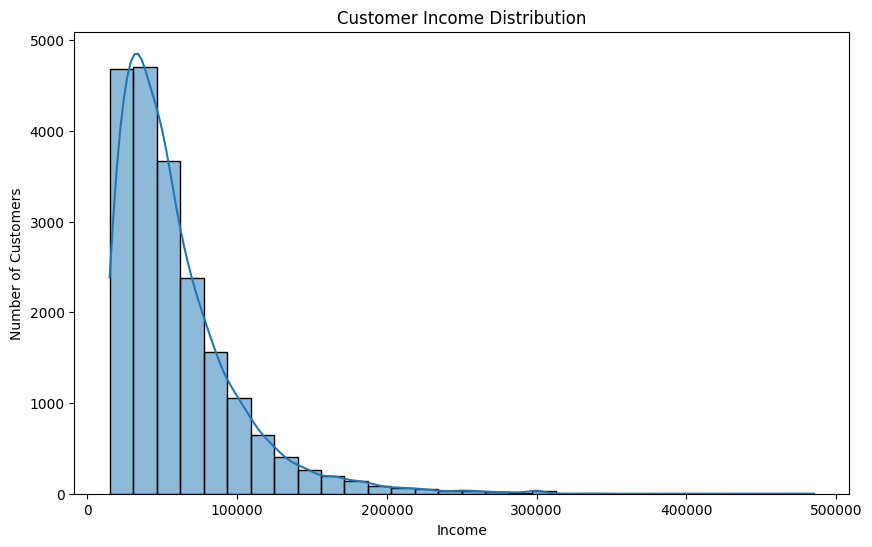

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='annualincome',
    bins=30,
    kde=True
)

plt.title('Customer Income Distribution')
plt.xlabel('Income')
plt.ylabel('Number of Customers')

plt.show()

Income Statistics

In [ ]:
income_summary = df['annualincome'].describe()

display(income_summary)

,annualincome
count,20000.000000
mean,59161.473550
std,40350.845168
min,15000.000000
25%,31679.000000
50%,48566.000000
75%,74391.000000
max,485341.000000


Employment Status Analysis

In [ ]:
print(df['employmentstatus'].value_counts(dropna=False))

employmentstatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64


In [ ]:
employment_summary = (
    df['employmentstatus']
    .value_counts()
    .reset_index()
)

employment_summary.columns = [
    'EmploymentStatus',
    'CustomerCount'
]

display(employment_summary)

,EmploymentStatus,CustomerCount
0,Employed,17036
1,Self-Employed,1573
2,Unemployed,1391


Employment  Status Chart

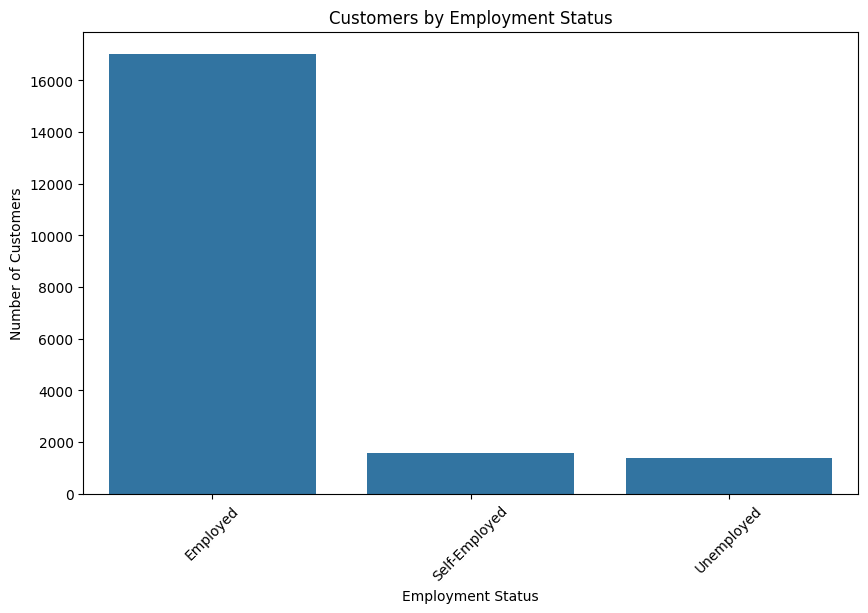

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='employmentstatus',
    order=df['employmentstatus'].value_counts().index
)

plt.title('Customers by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)

plt.show()

Age Distribution

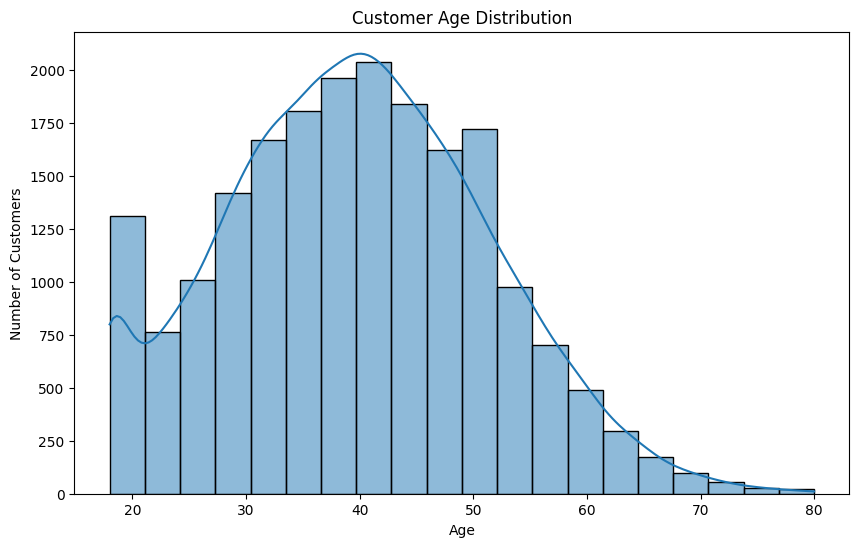

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='age',
    bins=20,
    kde=True
)

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

Age Groups

In [ ]:
if 'AgeGroup' in df.columns:
    print(df['AgeGroup'].value_counts())

In [ ]:
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(
        df['age'],
        bins=[0, 25, 35, 45, 55, 65, 100],
        labels=[
            '18-25',
            '26-35',
            '36-45',
            '46-55',
            '56-65',
            '65+'
        ],
        include_lowest=True
    )

print(df['age_group'].value_counts().sort_index())

age_group
18-25    2382
26-35    4962
36-45    6470
46-55    4318
56-65    1565
66+       303
Name: count, dtype: int64


Age Group Chart

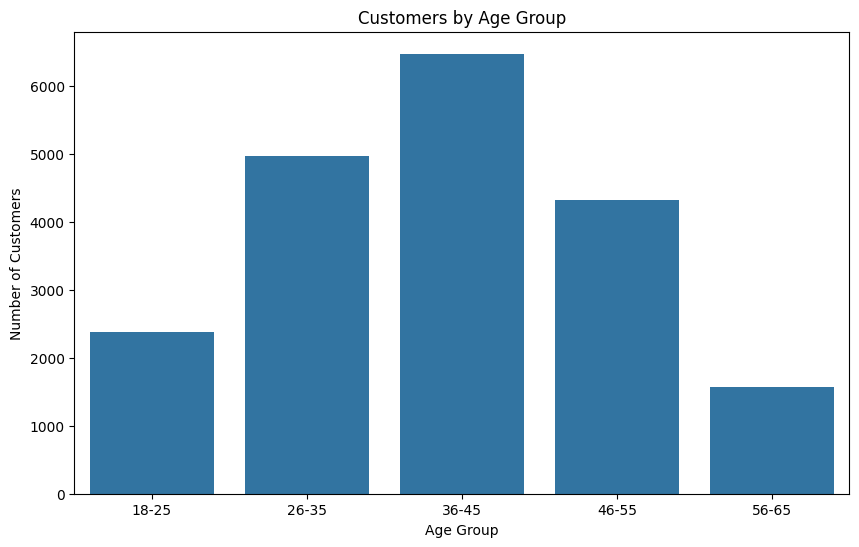

In [ ]:
age_order = [
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65',
    '65+'
]

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='age_group',
    order=[x for x in age_order if x in df['age_group'].astype(str).unique()]
)

plt.title('Customers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

Credit Score Distribution

In [ ]:
print(df['creditscore'].describe())

count    20000.000000
mean       571.612400
std         50.997358
min        343.000000
25%        540.000000
50%        578.000000
75%        609.000000
max        712.000000
Name: creditscore, dtype: float64


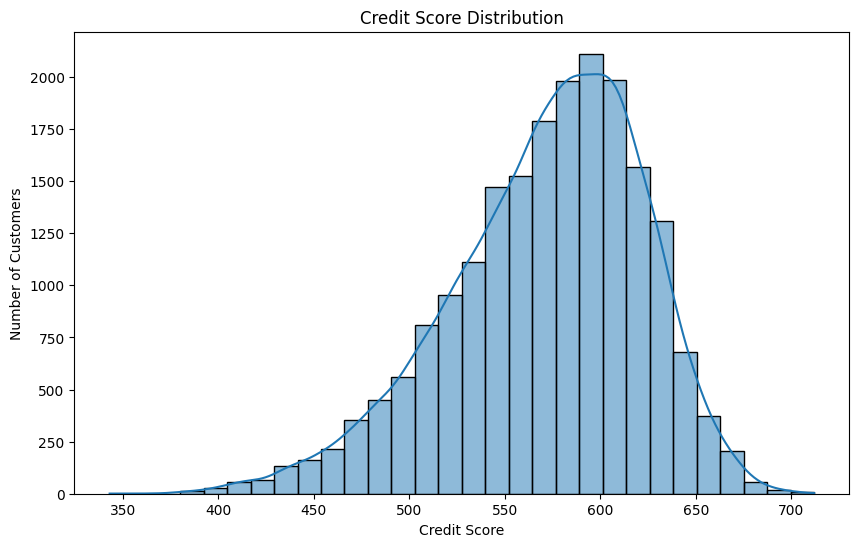

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='creditscore',
    bins=30,
    kde=True
)

plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')

plt.show()

Credit Score Categories

In [ ]:
if 'credit_score_group' in df.columns:
    display(df['credit_score_group'].value_counts())
else:
    print("Column 'credit_score_group' not found. Please ensure it is created.")

,count
credit_score_group,
Poor,10201
Fair,9647
Good,152


Credit Score Category Chart

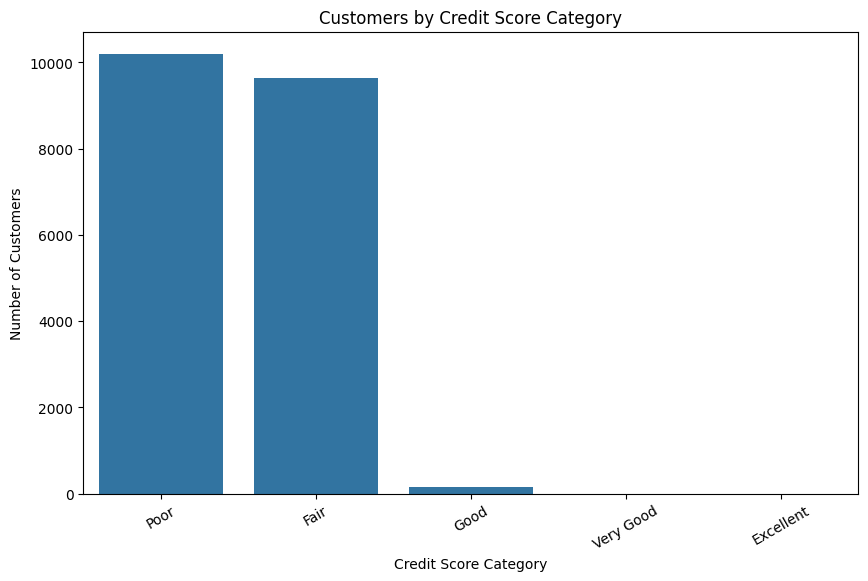

In [ ]:
credit_order = [
    'Poor',
    'Fair',
    'Good',
    'Very Good',
    'Excellent'
]

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='credit_score_group',
    order=credit_order
)

plt.title('Customers by Credit Score Category')
plt.xlabel('Credit Score Category')
plt.ylabel('Number of Customers')

plt.xticks(rotation=30)

plt.show()

Loan Analysis

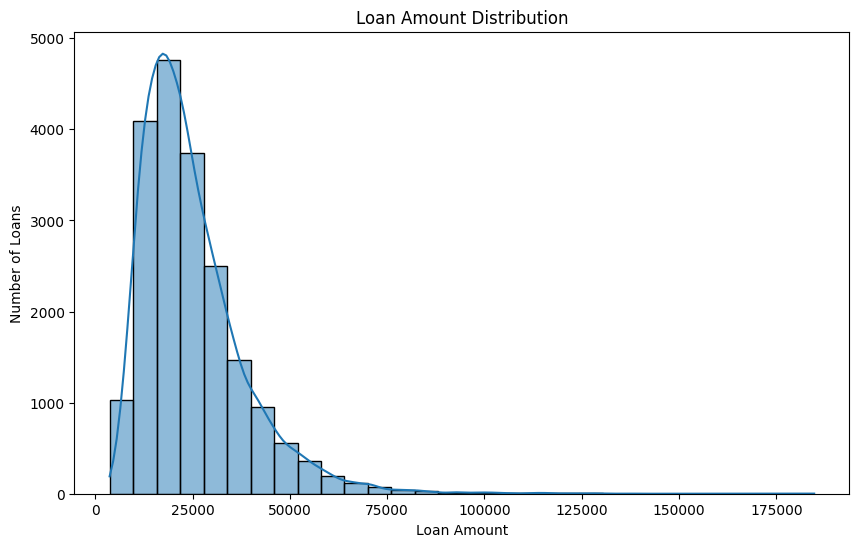

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='loanamount',
    bins=30,
    kde=True
)

plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Number of Loans')

plt.show()

Loan Amount Statistics

In [ ]:
loan_amount_summary = df['loanamount'].describe()

display(loan_amount_summary)

,loanamount
count,20000.000000
mean,24882.867800
std,13427.421217
min,3674.000000
25%,15575.000000
50%,21914.500000
75%,30835.000000
max,184732.000000


Loan Amount by Category

In [ ]:
if 'loanamount_category' not in df.columns:
    df['loanamount_category'] = pd.cut(
        df['loanamount'],
        bins=[0, 50000, 100000, 250000, 500000, np.inf],
        labels=[
            'Up to 50K',
            '50K-100K',
            '100K-250K',
            '250K-500K',
            '500K+'
        ],
        include_lowest=True
    )

display(df['loanamount_category'].value_counts())

,count
loanamount_category,
Up to 50K,18959
50K-100K,1008
100K-250K,33
250K-500K,0
500K+,0


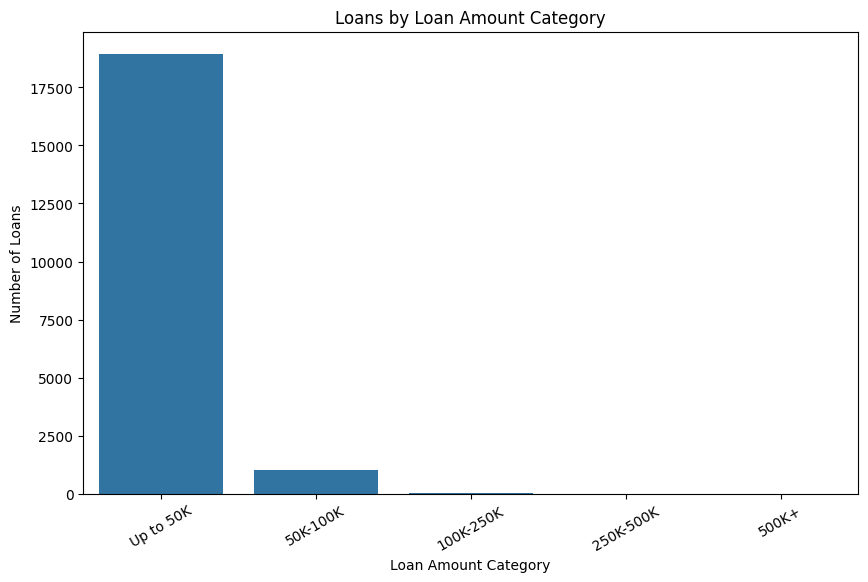

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='loanamount_category',
    order=df['loanamount_category'].value_counts().index
)

plt.title('Loans by Loan Amount Category')
plt.xlabel('Loan Amount Category')
plt.ylabel('Number of Loans')

plt.xticks(rotation=30)

plt.show()

Loan Purpose Analysis

In [ ]:
print(df['loanpurpose'].value_counts(dropna=False))

loanpurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64


In [ ]:
loan_purpose_summary = (
    df.groupby('loanpurpose')
      .agg(
          Applications=('loanpurpose', 'size'),
          Total_Loan_Amount=('loanamount', 'sum'),
          Average_Loan_Amount=('loanamount', 'mean')
      )
      .sort_values('Applications', ascending=False)
)

display(loan_purpose_summary)

,Applications,Total_Loan_Amount,Average_Loan_Amount
loanpurpose,,,
Home,5925,147091667,24825.597806
Debt Consolidation,5027,124674283,24800.931570
Auto,4034,100630067,24945.480169
Education,3008,75391503,25063.664561
Other,2006,49869836,24860.336989


Loan Purpose chart

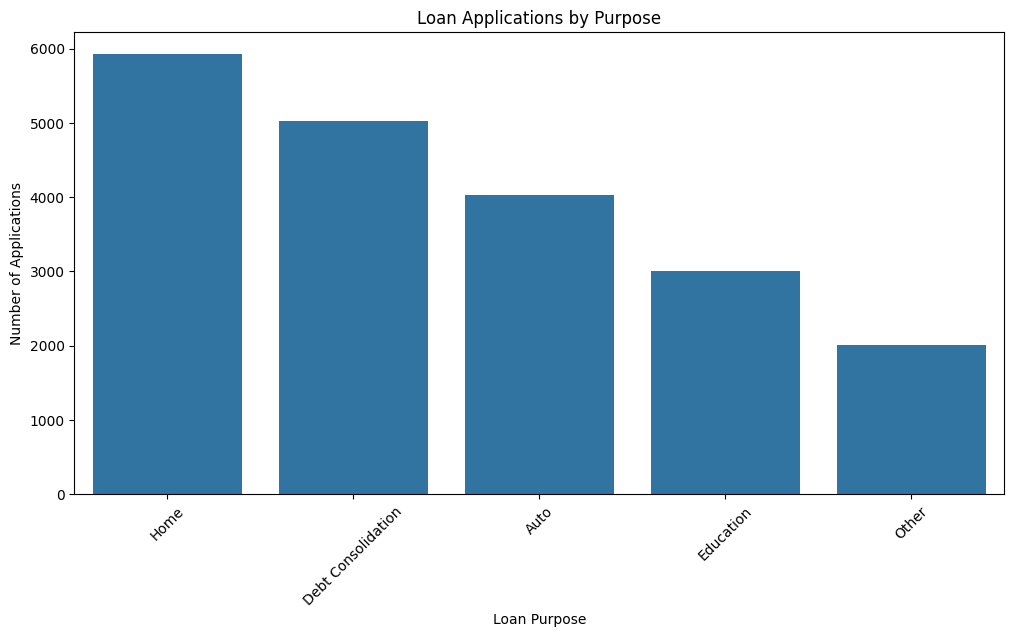

In [ ]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='loanpurpose',
    order=df['loanpurpose'].value_counts().index
)

plt.title('Loan Applications by Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Number of Applications')

plt.xticks(rotation=45)

plt.show()

Loan Term Analysis

In [ ]:
print(df['loanduration'].value_counts(dropna=False))

loanduration
48     3991
60     3982
36     3971
72     2046
24     1972
84     1059
96     1001
12      959
120     537
108     482
Name: count, dtype: int64


In [ ]:
loan_term_summary = (
    df.groupby('loanduration')
      .agg(
          Applications=('loanduration', 'size'),
          Average_Loan_Amount=('loanamount', 'mean')
      )
      .sort_index()
)

display(loan_term_summary)

,Applications,Average_Loan_Amount
loanduration,,
12,959,25244.452555
24,1972,24730.175963
36,3971,24786.101989
48,3991,24970.274868
60,3982,25020.119789
72,2046,24445.382698
84,1059,25240.271955
96,1001,24527.640360
108,482,26021.686722


Loan Term Cahrt

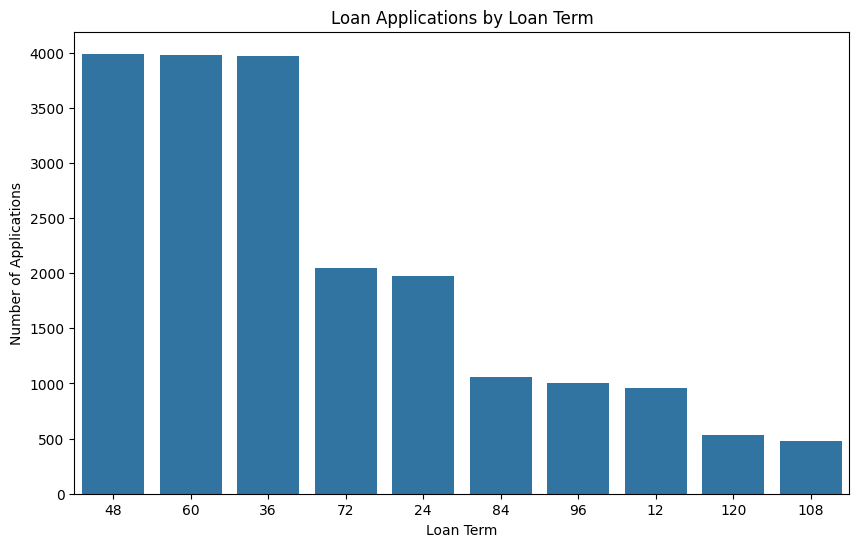

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='loanduration',
    order=df['loanduration'].value_counts().index
)

plt.title('Loan Applications by Loan Term')
plt.xlabel('Loan Term')
plt.ylabel('Number of Applications')

plt.show()

Application Trends

In [ ]:
date_columns = df.select_dtypes(
    include=['datetime64[ns]', 'datetime64[ns, UTC]']
).columns

print("Date columns:")
print(date_columns.tolist())

Date columns:
[]


In [ ]:
if 'applicationdate' in df.columns:
    df['applicationdate'] = pd.to_datetime(
        df['applicationdate'],
        errors='coerce'
    )

    print("Column 'applicationdate' converted to datetime.")

Column 'applicationdate' converted to datetime.


In [ ]:
if 'applicationdate' in df.columns:

    monthly_applications = (
        df.dropna(subset=['applicationdate'])
          .set_index('applicationdate')
          .resample('M')
          .size()
    )

    display(monthly_applications)
else:
    print("Column 'applicationdate' not found or not in datetime format.")

/tmp/ipykernel_1584/1764636349.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


,0
applicationdate,
2018-01-31,31
2018-02-28,28
2018-03-31,31
2018-04-30,30
2018-05-31,31
...,...
2072-06-30,30
2072-07-31,31
2072-08-31,31


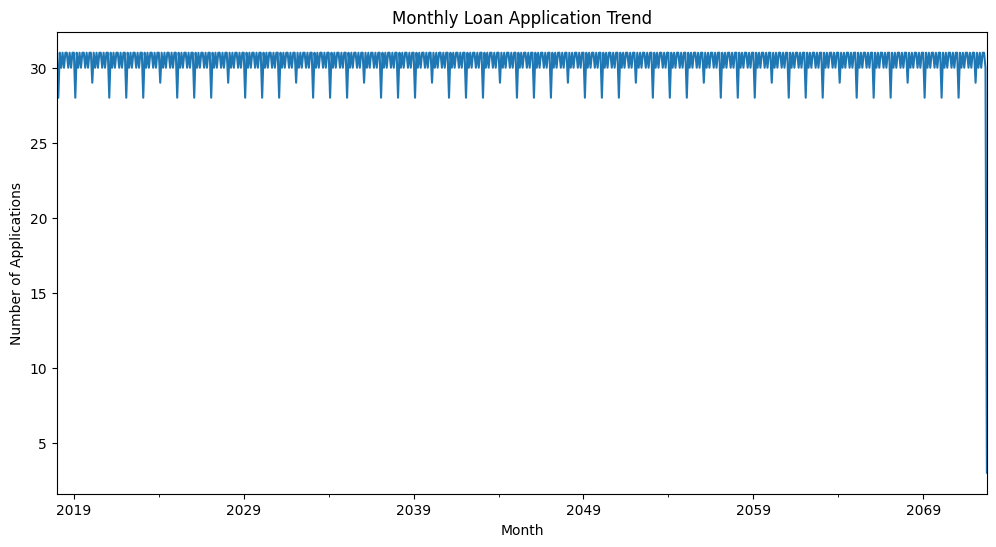

In [ ]:
if 'applicationdate' in df.columns and 'monthly_applications' in locals():

    plt.figure(figsize=(12, 6))

    monthly_applications.plot()

    plt.title('Monthly Loan Application Trend')
    plt.xlabel('Month')
    plt.ylabel('Number of Applications')

    plt.show()
else:
    print("Cannot plot monthly trends. 'applicationdate' column not found or 'monthly_applications' not calculated.")

CREDIT RISK ANALYSIS

Create a Default Flag

In [ ]:
df['DefaultFlag'] = df['previousloandefaults']

print(df['DefaultFlag'].value_counts())

DefaultFlag
0    17999
1     2001
Name: count, dtype: int64


Over all default rate

In [ ]:
overall_default_rate = df['DefaultFlag'].mean() * 100

print(f"Overall Default Rate: {overall_default_rate:.2f}%")

Overall Default Rate: 10.01%


Default Rate By Income Group

In [ ]:
if 'income_group' in df.columns:

    income_default_analysis = (
        df.groupby('income_group', observed=True)
          .agg(
              Customers=('income_group', 'size'),
              Defaults=('DefaultFlag', 'sum'),
              Default_Rate=('DefaultFlag', 'mean')
          )
    )

    income_default_analysis['Default_Rate'] *= 100

    income_default_analysis = income_default_analysis.sort_values(
        'Default_Rate',
        ascending=False
    )

    display(income_default_analysis)

,Customers,Defaults,Default_Rate
income_group,,,
Low,19993,2001,10.008503
Medium,7,0,0.000000


Income Group Default Rate Chart

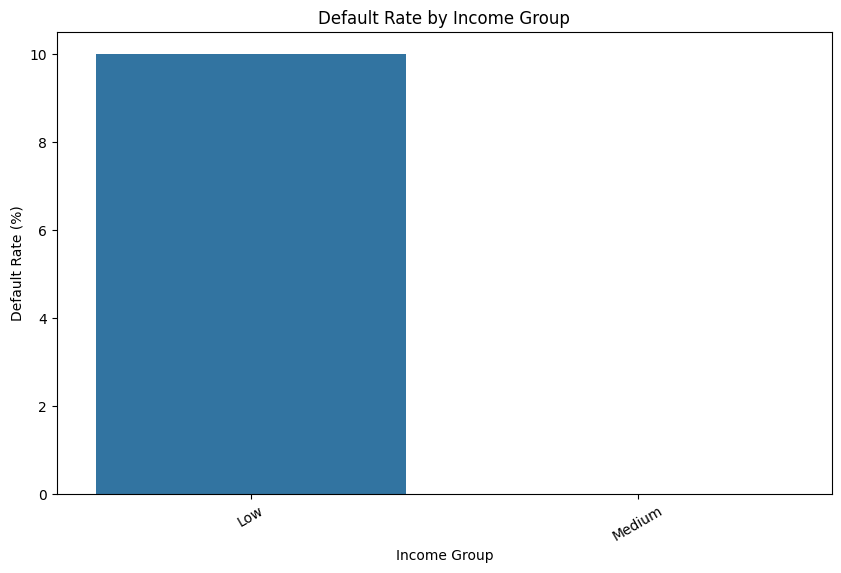

In [ ]:
if 'income_group' in df.columns:

    plot_data = income_default_analysis.reset_index()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=plot_data,
        x='income_group',
        y='Default_Rate'
    )

    plt.title('Default Rate by Income Group')
    plt.xlabel('Income Group')
    plt.ylabel('Default Rate (%)')

    plt.xticks(rotation=30)

    plt.show()

Default Rate by Credit Score Category

In [ ]:
# STEP 5: Credit Default Analysis

credit_default_analysis = (
    df.groupby(
        'credit_score_group',
        observed=True
    )
    .agg(
        Customers=('credit_score_group', 'size'),
        Defaults=('DefaultFlag', 'sum'),
        Default_Rate=('DefaultFlag', 'mean')
    )
)

credit_default_analysis['Default_Rate'] *= 100

credit_default_analysis = credit_default_analysis.sort_values(
    'Default_Rate',
    ascending=False
)

display(credit_default_analysis)

,Customers,Defaults,Default_Rate
credit_score_group,,,
Poor,10201,1057,10.361729
Fair,9647,933,9.671400
Good,152,11,7.236842


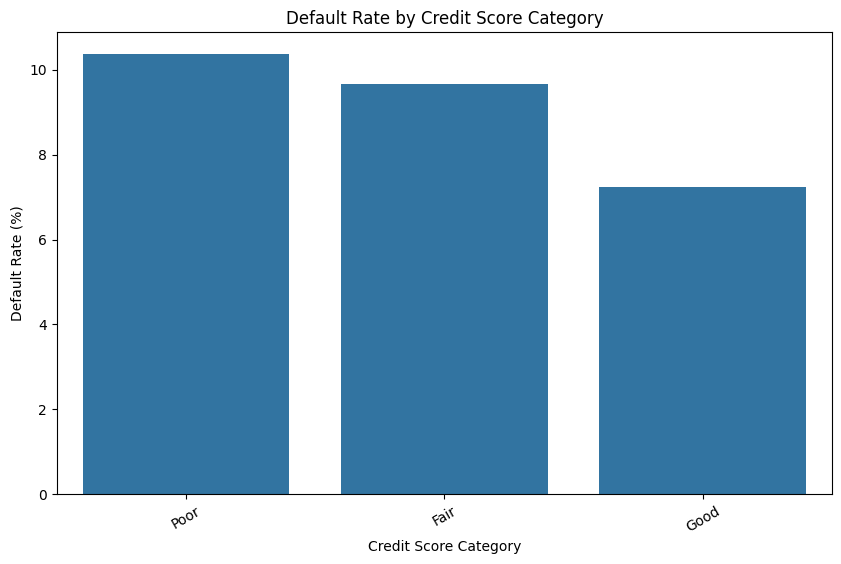

In [ ]:
plot_data = credit_default_analysis.reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x='credit_score_group',
    y='Default_Rate'
)

plt.title('Default Rate by Credit Score Category')
plt.xlabel('Credit Score Category')
plt.ylabel('Default Rate (%)')

plt.xticks(rotation=30)

plt.show()

Default Rate by Employment Status

In [ ]:
employment_default_analysis = (
    df.groupby('employmentstatus')
      .agg(
          Customers=('employmentstatus', 'size'),
          Defaults=('DefaultFlag', 'sum'),
          Default_Rate=('DefaultFlag', 'mean')
      )
)

employment_default_analysis['Default_Rate'] *= 100

employment_default_analysis = employment_default_analysis.sort_values(
    'Default_Rate',
    ascending=False
)

display(employment_default_analysis)

,Customers,Defaults,Default_Rate
employmentstatus,,,
Employed,17036,1734,10.178446
Unemployed,1391,136,9.777139
Self-Employed,1573,131,8.328036


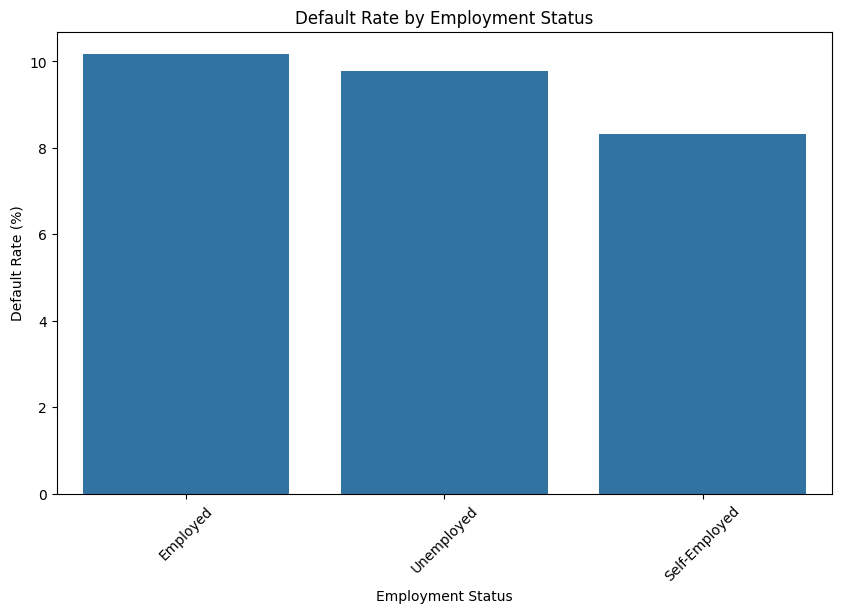

In [ ]:
plot_data = employment_default_analysis.reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x='employmentstatus',
    y='Default_Rate'
)

plt.title('Default Rate by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Default Rate (%)')

plt.xticks(rotation=45)

plt.show()

Create Debt-to-Income Categories

In [ ]:
print(df['debttoincomeratio'].describe())

count    20000.000000
mean         0.285735
std          0.160211
min          0.001720
25%          0.161035
50%          0.264454
75%          0.390327
max          0.902253
Name: debttoincomeratio, dtype: float64


In [ ]:
if 'debt_income_category' in df.columns:
    display(df['debt_income_category'].value_counts())
else:
    print("Column 'debt_income_category' not found. Please ensure it is created.")

,count
debt_income_category,
Low,6921
Moderate,6716
High,4172
Very High,2191


Default Rate by DTI Category

In [ ]:
dti_default_analysis = (
    df.groupby('debt_income_category', observed=True)
      .agg(
          Customers=('debt_income_category', 'size'),
          Defaults=('DefaultFlag', 'sum'),
          Default_Rate=('DefaultFlag', 'mean')
      )
)

dti_default_analysis['Default_Rate'] *= 100

display(dti_default_analysis)

,Customers,Defaults,Default_Rate
debt_income_category,,,
High,4172,442,10.594439
Low,6921,667,9.637336
Moderate,6716,663,9.871948
Very High,2191,229,10.451848


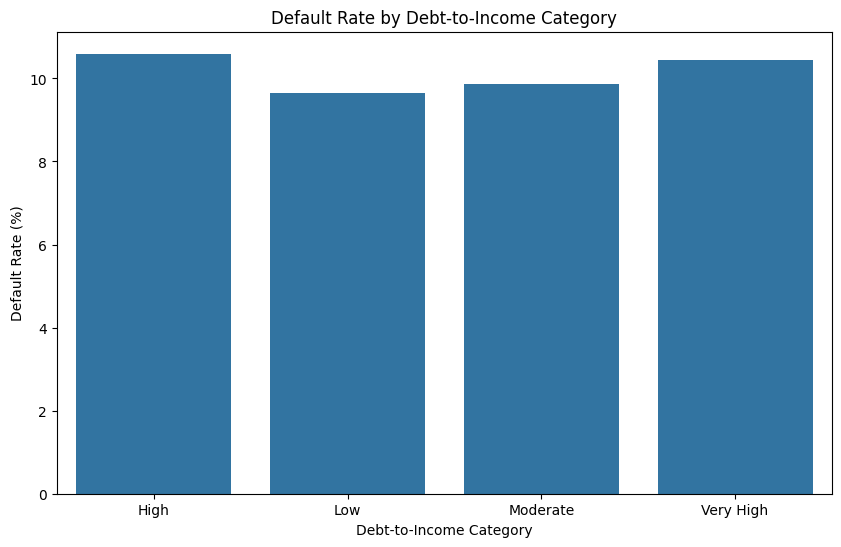

In [ ]:
plot_data = dti_default_analysis.reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x='debt_income_category',
    y='Default_Rate'
)

plt.title('Default Rate by Debt-to-Income Category')
plt.xlabel('Debt-to-Income Category')
plt.ylabel('Default Rate (%)')

plt.show()

Default Rate by Loan Purpose

In [ ]:
purpose_default_analysis = (
    df.groupby('loanpurpose')
      .agg(
          Applications=('loanpurpose', 'size'),
          Defaults=('DefaultFlag', 'sum'),
          Default_Rate=('DefaultFlag', 'mean')
      )
)

purpose_default_analysis['Default_Rate'] *= 100

purpose_default_analysis = purpose_default_analysis.sort_values(
    'Default_Rate',
    ascending=False
)

display(purpose_default_analysis)

,Applications,Defaults,Default_Rate
loanpurpose,,,
Other,2006,218,10.867398
Education,3008,308,10.239362
Debt Consolidation,5027,514,10.224786
Auto,4034,403,9.990084
Home,5925,558,9.417722


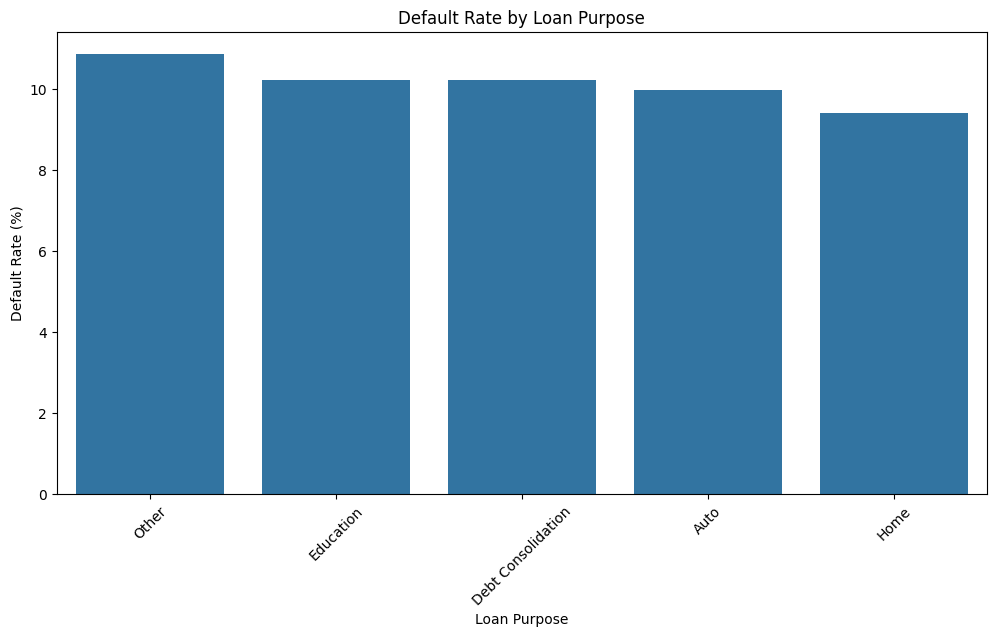

In [ ]:
plot_data = purpose_default_analysis.reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_data,
    x='loanpurpose',
    y='Default_Rate'
)

plt.title('Default Rate by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Default Rate (%)')

plt.xticks(rotation=45)

plt.show()

Default Rate by Age Group

In [ ]:
age_default_analysis = (
    df.groupby('age_group', observed=True)
      .agg(
          Customers=('age_group', 'size'),
          Defaults=('DefaultFlag', 'sum'),
          Default_Rate=('DefaultFlag', 'mean')
      )
)

age_default_analysis['Default_Rate'] *= 100

display(age_default_analysis)

,Customers,Defaults,Default_Rate
age_group,,,
18-25,2382,263,11.041142
26-35,4962,481,9.693672
36-45,6470,646,9.984544
46-55,4318,408,9.448819
56-65,1565,168,10.734824
66+,303,35,11.551155


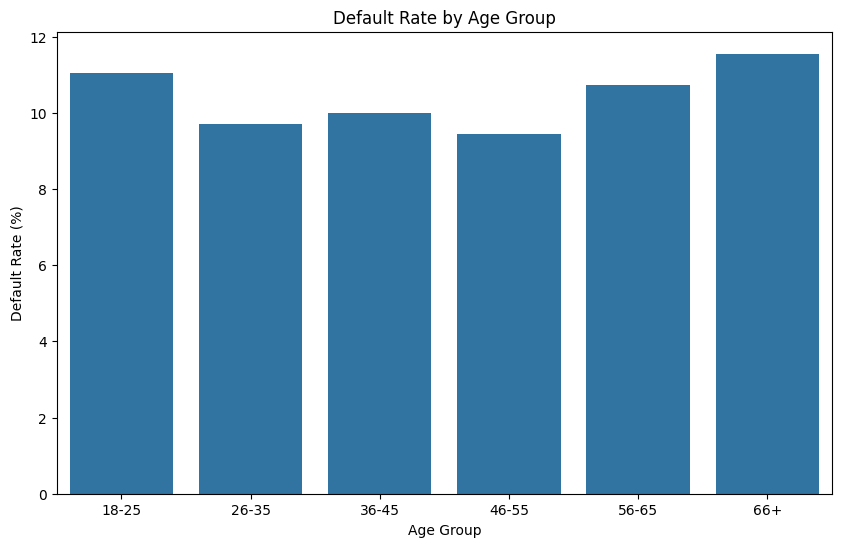

In [ ]:
plot_data = age_default_analysis.reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x='age_group',
    y='Default_Rate'
)

plt.title('Default Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Default Rate (%)')

plt.show()

Default Rate by Loan Amount Category

In [ ]:
loan_amount_default_analysis = (
    df.groupby('loan_amount_group', observed=True)
      .agg(
          Applications=('loan_amount_group', 'size'),
          Defaults=('DefaultFlag', 'sum'),
          Default_Rate=('DefaultFlag', 'mean')
      )
)

loan_amount_default_analysis['Default_Rate'] *= 100

display(loan_amount_default_analysis)

,Applications,Defaults,Default_Rate
loan_amount_group,,,
High,5001,498,9.958008
Low,5001,498,9.958008
Medium,4999,522,10.442088
Very High,4999,483,9.661932


Approval Analysis

In [ ]:
df['ApplicationStatus'] = df['loanapproved'].map({0: 'Rejected', 1: 'Approved'})

approval_analysis = (
    df.groupby('ApplicationStatus')
      .agg(
          Applications=('ApplicationStatus', 'size'),
          Average_Income=('annualincome', 'mean'),
          Average_Credit_Score=('creditscore', 'mean'),
          Average_Loan_Amount=('loanamount', 'mean')
      )
)

display(approval_analysis)

,Applications,Average_Income,Average_Credit_Score,Average_Loan_Amount
ApplicationStatus,,,,
Approved,4780,102210.551464,584.534100,19144.709414
Rejected,15220,45641.460907,567.554205,26684.996386


Approved vs Rejected Loan Amount

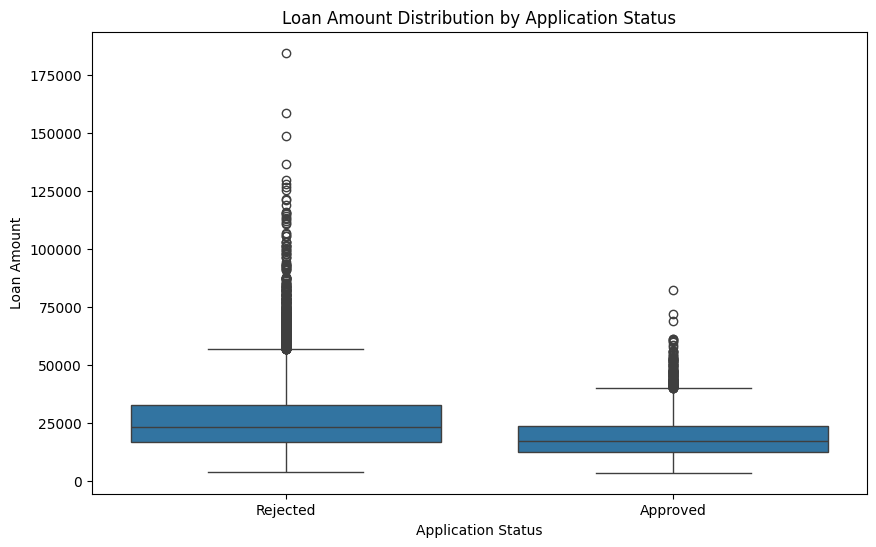

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='ApplicationStatus',
    y='loanamount'
)

plt.title('Loan Amount Distribution by Application Status')
plt.xlabel('Application Status')
plt.ylabel('Loan Amount')

plt.show()

Approved vs Rejected Credit Score

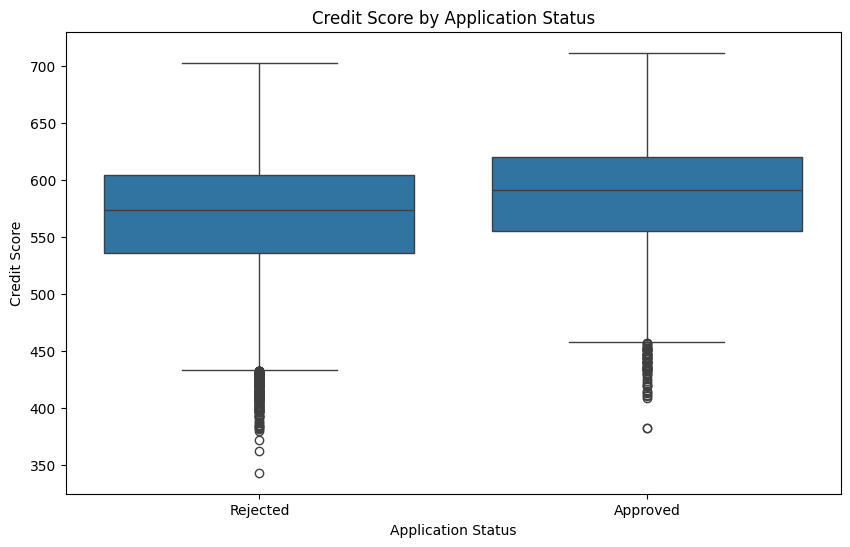

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='ApplicationStatus',
    y='creditscore'
)

plt.title('Credit Score by Application Status')
plt.xlabel('Application Status')
plt.ylabel('Credit Score')

plt.show()

Approved vs Rejected Income

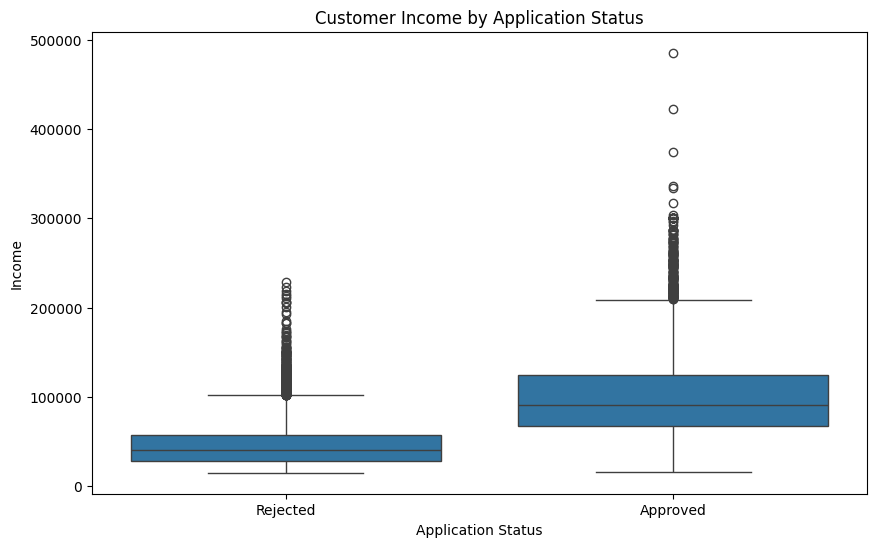

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='ApplicationStatus',
    y='annualincome'
)

plt.title('Customer Income by Application Status')
plt.xlabel('Application Status')
plt.ylabel('Income')

plt.show()

CORRELATION ANALYSIS

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

print("Numerical columns:")
print(numeric_df.columns.tolist())

Numerical columns:
['age', 'annualincome', 'creditscore', 'experience', 'loanamount', 'loanduration', 'numberofdependents', 'monthlydebtpayments', 'creditcardutilizationrate', 'numberofopencreditlines', 'numberofcreditinquiries', 'debttoincomeratio', 'bankruptcyhistory', 'previousloandefaults', 'paymenthistory', 'lengthofcredithistory', 'savingsaccountbalance', 'checkingaccountbalance', 'totalassets', 'totalliabilities', 'monthlyincome', 'utilitybillspaymenthistory', 'jobtenure', 'networth', 'baseinterestrate', 'interestrate', 'monthlyloanpayment', 'totaldebttoincomeratio', 'loanapproved', 'riskscore', 'loan_to_income_ratio', 'monthly_income_derived', 'monthly_debt_burden', 'DefaultFlag']


Correlation Matrix

In [ ]:
correlation_matrix = numeric_df.corr()

display(correlation_matrix)

,age,annualincome,creditscore,experience,loanamount,loanduration,numberofdependents,monthlydebtpayments,creditcardutilizationrate,numberofopencreditlines,numberofcreditinquiries,debttoincomeratio,bankruptcyhistory,previousloandefaults,paymenthistory,lengthofcredithistory,savingsaccountbalance,checkingaccountbalance,totalassets,totalliabilities,monthlyincome,utilitybillspaymenthistory,jobtenure,networth,baseinterestrate,interestrate,monthlyloanpayment,totaldebttoincomeratio,loanapproved,riskscore,loan_to_income_ratio,monthly_income_derived,monthly_debt_burden,DefaultFlag
age,1.000000,0.144774,0.323243,0.982980,-0.007492,-0.006992,-0.000287,0.015685,-0.001394,-0.001069,-0.002165,0.004438,0.010817,-0.003684,-2.487469e-03,-0.000139,0.004236,0.010145,0.012210,-0.001197,0.144634,-0.005601,-0.000773,0.014061,-0.238995,-0.202702,-0.021380,-0.111800,0.141029,-0.164304,-1.027100e-01,0.144774,-0.090986,-0.003684
annualincome,0.144774,1.000000,0.104045,0.145999,-0.004116,0.002972,-0.001244,-0.001082,-0.007935,-0.008175,-0.005016,0.001507,0.003816,0.004302,3.714571e-03,-0.005365,-0.001397,0.008613,-0.005158,-0.002353,0.989911,-0.012351,-0.000610,-0.004358,-0.074549,-0.063832,-0.004304,-0.532033,0.597900,-0.483289,-5.213690e-01,1.000000,-0.520210,0.004302
creditscore,0.323243,0.104045,1.000000,0.327664,-0.010834,-0.000762,-0.014453,0.011153,-0.009650,-0.008780,-0.001928,0.001913,0.008638,-0.007690,4.294509e-03,0.005217,-0.006316,0.005515,0.001342,-0.006722,0.104796,-0.006838,0.008069,0.001951,-0.722619,-0.598844,-0.063932,-0.115363,0.142000,-0.240198,-8.525311e-02,0.104045,-0.074143,-0.007690
experience,0.982980,0.145999,0.327664,1.000000,-0.007921,-0.007924,0.000136,0.018629,-0.001751,-0.002143,-0.002905,0.003139,0.009600,-0.002459,-3.346453e-03,-0.001132,0.005876,0.009292,0.013074,-0.000449,0.145950,-0.006603,-0.000762,0.015049,-0.242871,-0.206252,-0.021691,-0.112825,0.140755,-0.166496,-1.045607e-01,0.145999,-0.089853,-0.002459
loanamount,-0.007492,-0.004116,-0.010834,-0.007921,1.000000,-0.000436,-0.007005,0.021103,0.000806,0.000769,-0.006239,-0.009577,0.004844,-0.002352,-2.811058e-03,0.000580,0.001489,0.005408,-0.004238,0.000502,-0.005407,-0.012107,0.005364,-0.003679,0.385663,0.322824,0.780828,0.457175,-0.239496,0.137981,6.171721e-01,-0.004116,0.015444,-0.002352
loanduration,-0.006992,0.002972,-0.000762,-0.007924,-0.000436,1.000000,-0.001301,0.000068,-0.006160,0.001489,0.000978,0.001913,-0.000434,0.015646,1.982924e-03,0.013693,0.001579,-0.002832,-0.008297,0.003668,0.003067,-0.010105,0.003635,-0.008779,0.579215,0.487994,-0.385495,-0.213984,-0.094558,0.054550,6.848436e-03,0.002972,0.006168,0.015646
numberofdependents,-0.000287,-0.001244,-0.014453,0.000136,-0.007005,-0.001301,1.000000,-0.002396,0.011544,0.006033,-0.003749,-0.007981,-0.001154,0.006116,1.281406e-03,0.002705,-0.002080,0.002485,-0.006284,0.009942,-0.000414,0.008735,0.010910,-0.008423,0.006977,0.006749,-0.001390,-0.000358,0.001717,0.001686,-7.162967e-03,-0.001244,0.004837,0.006116
monthlydebtpayments,0.015685,-0.001082,0.011153,0.018629,0.021103,0.000068,-0.002396,1.000000,0.005420,0.006280,0.009889,0.001205,-0.007493,0.002713,-3.347394e-03,-0.004115,-0.004223,0.001909,0.003070,-0.004211,-0.000356,0.001638,0.005863,0.004430,0.000010,0.003895,0.018021,0.219453,-0.070415,0.036938,1.142850e-02,-0.001082,0.613587,0.002713
creditcardutilizationrate,-0.001394,-0.007935,-0.009650,-0.001751,0.000806,-0.006160,0.011544,0.005420,1.000000,0.001491,0.001708,0.002231,0.010892,-0.004450,4.516682e-03,0.007446,0.004026,-0.002115,-0.005047,-0.007778,-0.009381,0.013040,-0.006979,-0.003506,0.003668,0.001030,0.004366,0.010490,-0.010466,0.108758,9.902811e-03,-0.007935,0.009501,-0.004450
numberofopencreditlines,-0.001069,-0.008175,-0.008780,-0.002143,0.000769,0.001489,0.006033,0.006280,0.001491,1.000000,0.000446,0.004363,-0.001612,0.012600,2.387506e-03,0.003653,0.009167,-0.005282,-0.003896,-0.008406,-0.008050,-0.010497,0.007298,-0.002013,0.007457,0.008090,-0.005058,0.003471,-0.004769,0.007762,4.97551

Correlation Heatmap

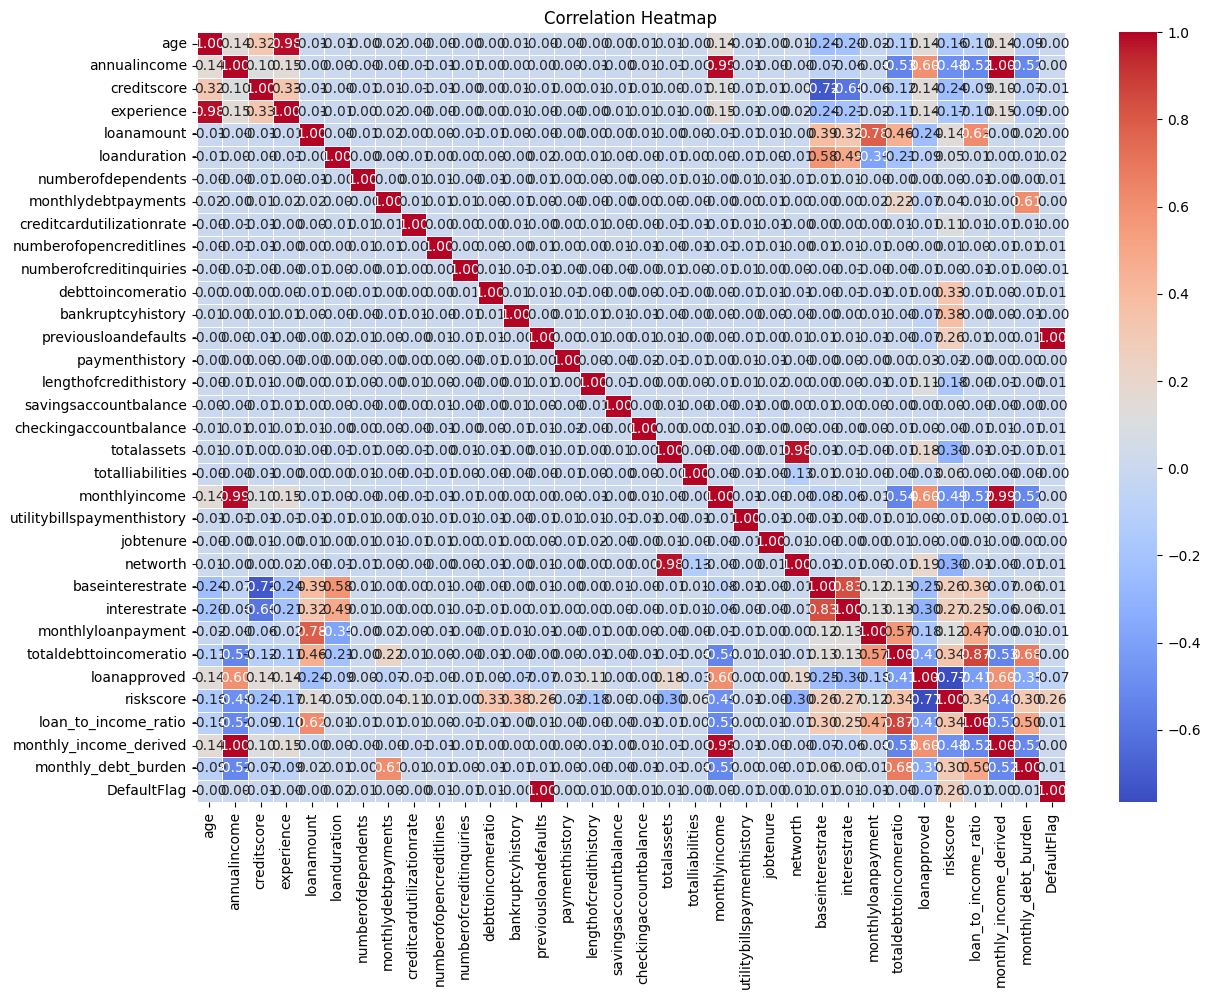

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')

plt.show()

Strongest Correlations

In [ ]:
correlation_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    'Variable_1',
    'Variable_2',
    'Correlation'
]

correlation_pairs['Absolute_Correlation'] = (
    correlation_pairs['Correlation'].abs()
)

correlation_pairs = correlation_pairs.sort_values(
    'Absolute_Correlation',
    ascending=False
)

display(correlation_pairs.head(15))

,Variable_1,Variable_2,Correlation,Absolute_Correlation
370,previousloandefaults,DefaultFlag,1.000000,1.000000
62,annualincome,monthly_income_derived,1.000000,1.000000
480,monthlyincome,monthly_income_derived,0.989911,0.989911
51,annualincome,monthlyincome,0.989911,0.989911
2,age,experience,0.982980,0.982980
445,totalassets,networth,0.978997,0.978997
542,totaldebttoincomeratio,loan_to_income_ratio,0.867466,0.867466
516,baseinterestrate,interestrate,0.834557,0.834557
147,loanamount,monthlyloanpayment,0.780828,0.780828
546,loanapproved,riskscore,-0.766137,0.766137


CREDIT RISK SUMMARY TABLE

In [ ]:
risk_summary = pd.DataFrame({
    'Risk Dimension': [
        'Income Group',
        'Credit Score Category',
        'Employment Status',
        'DTI Category',
        'Loan Purpose',
        'Age Group'
    ],
    'Analysis': [
        'Default Rate by Income Group',
        'Default Rate by Credit Score',
        'Default Rate by Employment Status',
        'Default Rate by DTI Category',
        'Default Rate by Loan Purpose',
        'Default Rate by Age Group'
    ]
})

display(risk_summary)

,Risk Dimension,Analysis
0,Income Group,Default Rate by Income Group
1,Credit Score Category,Default Rate by Credit Score
2,Employment Status,Default Rate by Employment Status
3,DTI Category,Default Rate by DTI Category
4,Loan Purpose,Default Rate by Loan Purpose
5,Age Group,Default Rate by Age Group


AUTOMATIC BUSINESS INSIGHT SUPPORT

Credit Score

In [ ]:
credit_risk_high = credit_default_analysis['Default_Rate'].idxmax()
credit_risk_low = credit_default_analysis['Default_Rate'].idxmin()

print("Highest observed default-rate credit category:",
      credit_risk_high)

print("Lowest observed default-rate credit category:",
      credit_risk_low)

Highest observed default-rate credit category: Poor
Lowest observed default-rate credit category: Good


Employment

In [ ]:
employment_risk_high = employment_default_analysis['Default_Rate'].idxmax()
employment_risk_low = employment_default_analysis['Default_Rate'].idxmin()

print("Highest observed default-rate employment group:",
      employment_risk_high)

print("Lowest observed default-rate employment group:",
      employment_risk_low)

Highest observed default-rate employment group: Employed
Lowest observed default-rate employment group: Self-Employed


DTI

In [ ]:
dti_risk_high = dti_default_analysis['Default_Rate'].idxmax()
dti_risk_low = dti_default_analysis['Default_Rate'].idxmin()

print("Highest observed default-rate DTI category:",
      dti_risk_high)

print("Lowest observed default-rate DTI category:",
      dti_risk_low)

Highest observed default-rate DTI category: High
Lowest observed default-rate DTI category: Low


Save EDA Results

In [ ]:
import os

output_folder = "/content/banking_eda_outputs"

os.makedirs(output_folder, exist_ok=True)

print("Output folder created:", output_folder)

Output folder created: /content/banking_eda_outputs


Save KPI Results

In [ ]:
kpi_summary.to_csv(
    f"{output_folder}/banking_kpi_summary.csv",
    index=False
)

print("KPI summary saved.")

KPI summary saved.


Save Risk Analysis Tables

In [ ]:
if 'IncomeGroup' in df.columns:
    income_default_analysis.to_csv(
        f"{output_folder}/default_rate_by_income.csv"
    )

credit_default_analysis.to_csv(
    f"{output_folder}/default_rate_by_credit_score.csv"
)

employment_default_analysis.to_csv(
    f"{output_folder}/default_rate_by_employment.csv"
)

dti_default_analysis.to_csv(
    f"{output_folder}/default_rate_by_dti.csv"
)

purpose_default_analysis.to_csv(
    f"{output_folder}/default_rate_by_loan_purpose.csv"
)

age_default_analysis.to_csv(
    f"{output_folder}/default_rate_by_age.csv"
)

print("Risk analysis tables saved.")

Risk analysis tables saved.


Save Final  Dataset

In [ ]:
final_eda_dataset_path = (
    f"{output_folder}/banking_day3_eda_dataset.csv"
)

df.to_csv(
    final_eda_dataset_path,
    index=False
)

print("Final Day 3 dataset saved:")
print(final_eda_dataset_path)

Final Day 3 dataset saved:
/content/banking_eda_outputs/banking_day3_eda_dataset.csv


Check the Final Dataset

In [ ]:
print("Final dataset shape:", df.shape)

display(df.head())

print("\nFinal columns:")
print(df.columns.tolist())

Final dataset shape: (20000, 48)


,applicationdate,age,annualincome,creditscore,employmentstatus,educationlevel,experience,loanamount,loanduration,maritalstatus,numberofdependents,homeownershipstatus,monthlydebtpayments,creditcardutilizationrate,numberofopencreditlines,numberofcreditinquiries,debttoincomeratio,bankruptcyhistory,loanpurpose,previousloandefaults,paymenthistory,lengthofcredithistory,savingsaccountbalance,checkingaccountbalance,totalassets,totalliabilities,monthlyincome,utilitybillspaymenthistory,jobtenure,networth,baseinterestrate,interestrate,monthlyloanpayment,totaldebttoincomeratio,loanapproved,riskscore,income_group,age_group,loan_amount_group,credit_score_group,debt_income_category,loan_risk_category,loan_to_income_ratio,monthly_income_derived,monthly_debt_burden,loanamount_category,DefaultFlag,ApplicationStatus
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,Low,36-45,Low,Fair,High,Medium Risk,0.329228,3329.000000,0.054971,Up to 50K,0,Rejected
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,Low,36-45,High,Fair,Moderate,Medium Risk,0.655897,3309.083333,0.149890,Up to 50K,0,Rejected
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,Low,46-55,Medium,Poor,Moderate,Medium Risk,0.432841,3393.666667,0.265789,Up to 50K,0,Rejected
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,Low,56-65,Very High,Poor,High,Medium Risk,0.548579,5757.000000,0.131145,Up to 50K,0,Rejected
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,Low,36-45,Low,Fair,Low,Medium Risk,0.088937,8605.333333,0.031841,Up to 50K,0,Approved



Final columns:
['applicationdate', 'age', 'annualincome', 'creditscore', 'employmentstatus', 'educationlevel', 'experience', 'loanamount', 'loanduration', 'maritalstatus', 'numberofdependents', 'homeownershipstatus', 'monthlydebtpayments', 'creditcardutilizationrate', 'numberofopencreditlines', 'numberofcreditinquiries', 'debttoincomeratio', 'bankruptcyhistory', 'loanpurpose', 'previousloandefaults', 'paymenthistory', 'lengthofcredithistory', 'savingsaccountbalance', 'checkingaccountbalance', 'totalassets', 'totalliabilities', 'monthlyincome', 'utilitybillspaymenthistory', 'jobtenure', 'networth', 'baseinterestrate', 'interestrate', 'monthlyloanpayment', 'totaldebttoincomeratio', 'loanapproved', 'riskscore', 'income_group', 'age_group', 'loan_amount_group', 'credit_score_group', 'debt_income_category', 'loan_risk_category', 'loan_to_income_ratio', 'monthly_income_derived', 'monthly_debt_burden', 'loanamount_category', 'DefaultFlag', 'ApplicationStatus']


Check the current DataFrame columns

In [ ]:
# Display all column names
print("Dataset Columns:")
print(df.columns.tolist())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display first 5 rows
display(df.head())

Dataset Columns:
['applicationdate', 'age', 'annualincome', 'creditscore', 'employmentstatus', 'educationlevel', 'experience', 'loanamount', 'loanduration', 'maritalstatus', 'numberofdependents', 'homeownershipstatus', 'monthlydebtpayments', 'creditcardutilizationrate', 'numberofopencreditlines', 'numberofcreditinquiries', 'debttoincomeratio', 'bankruptcyhistory', 'loanpurpose', 'previousloandefaults', 'paymenthistory', 'lengthofcredithistory', 'savingsaccountbalance', 'checkingaccountbalance', 'totalassets', 'totalliabilities', 'monthlyincome', 'utilitybillspaymenthistory', 'jobtenure', 'networth', 'baseinterestrate', 'interestrate', 'monthlyloanpayment', 'totaldebttoincomeratio', 'loanapproved', 'riskscore', 'income_group', 'age_group', 'loan_amount_group', 'credit_score_group', 'debt_income_category', 'loan_risk_category', 'loan_to_income_ratio', 'monthly_income_derived', 'monthly_debt_burden', 'loanamount_category', 'DefaultFlag', 'ApplicationStatus']

Dataset Shape:
(20000, 48)


,applicationdate,age,annualincome,creditscore,employmentstatus,educationlevel,experience,loanamount,loanduration,maritalstatus,numberofdependents,homeownershipstatus,monthlydebtpayments,creditcardutilizationrate,numberofopencreditlines,numberofcreditinquiries,debttoincomeratio,bankruptcyhistory,loanpurpose,previousloandefaults,paymenthistory,lengthofcredithistory,savingsaccountbalance,checkingaccountbalance,totalassets,totalliabilities,monthlyincome,utilitybillspaymenthistory,jobtenure,networth,baseinterestrate,interestrate,monthlyloanpayment,totaldebttoincomeratio,loanapproved,riskscore,income_group,age_group,loan_amount_group,credit_score_group,debt_income_category,loan_risk_category,loan_to_income_ratio,monthly_income_derived,monthly_debt_burden,loanamount_category,DefaultFlag,ApplicationStatus
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,Low,36-45,Low,Fair,High,Medium Risk,0.329228,3329.000000,0.054971,Up to 50K,0,Rejected
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,Low,36-45,High,Fair,Moderate,Medium Risk,0.655897,3309.083333,0.149890,Up to 50K,0,Rejected
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,Low,46-55,Medium,Poor,Moderate,Medium Risk,0.432841,3393.666667,0.265789,Up to 50K,0,Rejected
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,Low,56-65,Very High,Poor,High,Medium Risk,0.548579,5757.000000,0.131145,Up to 50K,0,Rejected
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,Low,36-45,Low,Fair,Low,Medium Risk,0.088937,8605.333333,0.031841,Up to 50K,0,Approved


Check the data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   applicationdate             20000 non-null  datetime64[ns]
 1   age                         20000 non-null  int64         
 2   annualincome                20000 non-null  int64         
 3   creditscore                 20000 non-null  int64         
 4   employmentstatus            20000 non-null  object        
 5   educationlevel              20000 non-null  object        
 6   experience                  20000 non-null  int64         
 7   loanamount                  20000 non-null  int64         
 8   loanduration                20000 non-null  int64         
 9   maritalstatus               20000 non-null  object        
 10  numberofdependents          20000 non-null  int64         
 11  homeownershipstatus         20000 non-null  object    

Display unique values in categorical columns

In [ ]:
for column in df.select_dtypes(include="object").columns:
    print(f"\nColumn: {column}")
    print(df[column].unique()[:20])


Column: employmentstatus
['Employed' 'Self-Employed' 'Unemployed']

Column: educationlevel
['Master' 'Associate' 'Bachelor' 'High School' 'Doctorate']

Column: maritalstatus
['Married' 'Single' 'Divorced' 'Widowed']

Column: homeownershipstatus
['Own' 'Mortgage' 'Rent' 'Other']

Column: loanpurpose
['Home' 'Debt Consolidation' 'Education' 'Other' 'Auto']

Column: income_group
['Low' 'Medium']

Column: age_group
['36-45' '46-55' '56-65' '26-35' '18-25' '66+']

Column: loan_amount_group
['Low' 'High' 'Medium' 'Very High']

Column: credit_score_group
['Fair' 'Poor' 'Good']

Column: debt_income_category
['High' 'Moderate' 'Low' 'Very High']

Column: loan_risk_category
['Medium Risk' 'High Risk' 'Low Risk']

Column: ApplicationStatus
['Rejected' 'Approved']


Prepare the Dataset for MySQL

In [ ]:
# Export cleaned and feature-engineered dataset

df.to_csv(
    "banking_day4_sql_dataset.csv",
    index=False
)

print("Dataset exported successfully!")

Dataset exported successfully!


Download the CSV

In [ ]:
from google.colab import files

files.download("banking_day4_sql_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>